In [1]:
import sys
import os
sys.path = [p for p in sys.path if "ParaView" not in p]
sys.path.append("/home/haseeb/Notebooks/Parameteric_DMD_cylinder_2D_modules")
import math
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['mathtext.fontset'] = 'cm'   # Computer Modern
import matplotlib.tri as mtri
from matplotlib.patches import Circle, Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from flowtorch import DATASETS
from flowtorch.data import FOAMDataloader, mask_box
from flowtorch.analysis import DMD
from sklearn.utils.extmath import randomized_svd
from scipy.interpolate import griddata



from pathlib import Path
import re
# For High Quality Visuals
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 160  # crisp visuals

## Step 1. Defining training and test parameters

We define a training set *P*, for the partitioned Dynamic Mode Decomposition as:
$$
P = \{\mu_1, \mu_2, \dots, \mu_P\}, \quad 
\mu_j \equiv Re_j $$

where
- $P$ : set of training parameters which are Reynolds numbers $Re$ in this case. 
- $\mu_j$ : $j$‑th training parameter in $P$ 

And, the unseen parameter is given as $\mu^\star$, for which the spectral information ($\lambda$, $\phi$, $b$) of the forecasted DMD from the training set $P$ is interpolated.

$$
\mu^\star \equiv Re^\star
$$

where 
- $\lambda_j^{(\mu_j)}$ : DMD eigenvalue associated with mode $j$ at parameter $\mu_j$
- $\phi_j^{(\mu_j)}$: $j$‑th DMD mode vector  
- $Re^\star$: test Reynolds number
- $b_{jk}^{(\mu_j)}$: amplitude of mode $j$ at time $k$


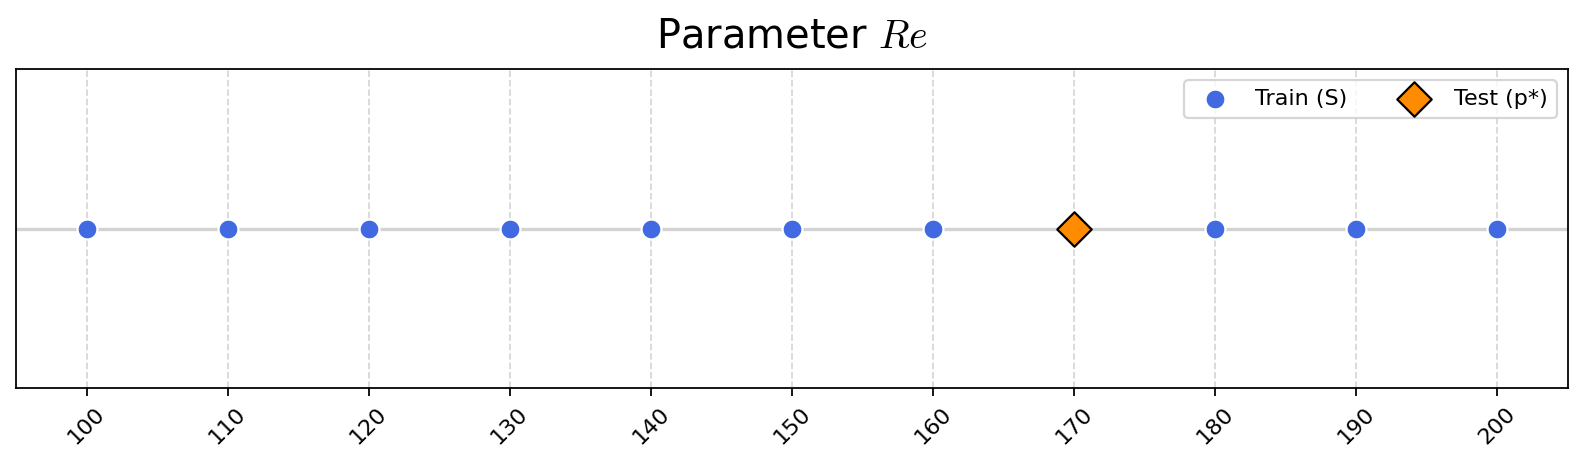

In [2]:
# Training and test parameters (parameter set P and test parameter μ*)

# Training parameter set P = {μ1, ..., μP}, i.e., Reynolds numbers
Re_list = np.array([100, 110, 120, 130, 140, 150, 160, 180, 190, 200])  # μ: training parameters

# Test parameter μ* (unseen Reynolds number)
Re_test = 170  # μ*: test parameter
# Global reference length and viscosity
L_ref = 0.1   # cylinder diameter [m]
nu = 1e-3     # kinematic viscosity [m^2/s] (example value, adjust to your case)

# Geometry parameters (from your blockMeshDict)
cylinderX = 0.2   # cylinder center x [m]
cylinderY = 0.2   # cylinder center y [m]
radius    = 0.05  # cylinder radius [m]


# Calculate reference velocities for non-dimensionalization directly from Re
U_ref_dict = {Re: Re * nu / L_ref for Re in Re_list}
U_ref_test = Re_test * nu / L_ref

# Visualization of parameter set S and test parameter p*
fig, ax = plt.subplots(figsize=(10, 3))
plt.title('Parameter $Re$', fontsize=18, pad=10)

# Plot all training parameters (S)
ax.scatter(Re_list, np.zeros_like(Re_list), 
           marker='o', s=80, color='royalblue', edgecolor='white', 
           label='Train (S)', zorder=3)

# Plot test parameter (p*)
ax.scatter(Re_test, 0, 
           marker='D', s=120, color='darkorange', edgecolor='black', 
           label='Test (p*)', zorder=4)

# Formatting
plt.xticks(np.append(Re_list, Re_test), rotation=45, fontsize=10)
plt.yticks([])
ax.axhline(0, color='lightgray', linewidth=1.5, zorder=1)   # baseline line
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(ncols=2, frameon=True, fontsize=10)

plt.tight_layout()
plt.show()


In [3]:
# Load and prepare data (velocity components Ux, Uy)

import os
from Flowtorch_DMD_cylinder_2D_modules import loader

# Base folder containing simulation data
base_path = os.path.expanduser("~/OpenFOAM/test_1")

# Time windows
training_window = (10.0, 15.0)
future_window   = (15.0, 20.0)

sampling_step = 1

# Load training data
train = loader.load_training_snapshots(
    Re_list=Re_list,
    base_path=base_path,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    training_window=training_window,
    future_window=future_window,
    sampling_step=sampling_step,
    fields=("U", "cl")
)

# Access training data
snapshot_dict             = train.snapshots
sampled_times_dict        = train.times
snapshot_future_dict      = train.future_snapshots
sampled_times_future_dict = train.future_times
masked_coords_dict        = {Re: train.coords for Re in Re_list}
num_points_dict           = {Re: train.num_points for Re in Re_list}

# Lift coefficient (training + future windows)
cl_train_dict        = train.cl_train
cl_train_times_dict  = train.cl_train_times
cl_future_dict       = train.cl_future
cl_future_times_dict = train.cl_future_times

# Load test data
future_times = sampled_times_future_dict[Re_list[0]]
path_test = f"{base_path}/cylinder_2D_Re{Re_test}"

test_data = loader.load_test_snapshots(
    Re=Re_test,
    path=path_test,
    mask_box=mask_box,
    FOAMDataloader=FOAMDataloader,
    future_times=future_times,
    sampling_step=sampling_step,
    fields=("U", "cl")
)

# Access test forecast data
snapshot_test_future      = test_data.test_future_snapshots
sampled_times_test_future = test_data.test_future_times
mask_test                 = test_data.mask
coords_test               = test_data.coords
num_points_test           = test_data.num_points

# Lift coefficient for test case (future window)
cl_test       = test_data.cl_test
cl_test_times = test_data.cl_test_times


[2026-04-06 22:33:09] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-06 22:33:09] INFO     Loading precomputed cell centers and volumes from processor1/constant


Loaded training and future snapshots for Re=100
Loaded training and future snapshots for Re=110
Loaded training and future snapshots for Re=120
Loaded training and future snapshots for Re=130
Loaded training and future snapshots for Re=140
Loaded training and future snapshots for Re=150
Loaded training and future snapshots for Re=160
Loaded training and future snapshots for Re=180
Loaded training and future snapshots for Re=190


[2026-04-06 22:33:36] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-06 22:33:36] INFO     Loading precomputed cell centers and volumes from processor1/constant


Loaded training and future snapshots for Re=200
Loaded test future snapshots for Re=170



## Step 2. Train partitioned DMD

For each training parameter $\mu_j \in P = \{\mu_1, \mu_2, \dots, \mu_p\}$ i.e., Reynolds numbers $Re$, the fitted DMD operator is obtained via

$$
A^{(\mu_j)} \;\; \approx \;\; Y^{(\mu_j)} \, \big(X^{(\mu_j)})^{\dagger}
$$


where  
- $\mu_j$ : $j$‑th training parameter in the set $S$  
- $Re$ : Reynolds number corresponding to $\mu_j$  
- $X^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : snapshot matrix at times $t_1, \dots, t_{n_{\text{time}}-1}$  
- $Y^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times (n_{\text{time}}-1)}$ : shifted snapshot matrix at times $t_2, \dots, t_{n_{\text{time}}}$  
- $A^{(\mu_j)}$ : DMD regression operator advancing the reduced state forward in time  



In [4]:
dmd_dict = {}

for Re in Re_list:
    # Flow snapshots
    X_flow = snapshot_dict[Re]   # shape: (space_dim, n_time)

    # Cl time series
    cl = cl_train_dict[Re]       # shape: (n_time,)
    cl = cl.reshape(1, -1)       # make it (1, n_time)

    # Augment the state
    X_aug = np.vstack([X_flow, cl])

    # Convert to tensor
    X_p = pt.tensor(X_aug, dtype=pt.float64)

    # dt
    times = np.array(sampled_times_dict[Re], dtype=float)
    dt = times[1] - times[0]

    # Fit DMD
    dmd = DMD(X_p, dt=dt, rank=30,tlsq=False, unitary=False, optimal=False, forward_backward=False)

    dmd_dict[int(Re)] = dmd


[2026-04-06 22:33:37] INFO     Computing economy SVD via Gram matrix and eigendecomposition


[2026-04-06 22:33:37] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:37] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:37] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:37] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:38] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:38] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:38] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:38] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:38] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:38] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:38] INFO     Truncating SVD at index 30/500
[2026-04-06 22:33:38] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:33:38] INFO     Truncating SVD at index 30/500
[2026-04-06 22

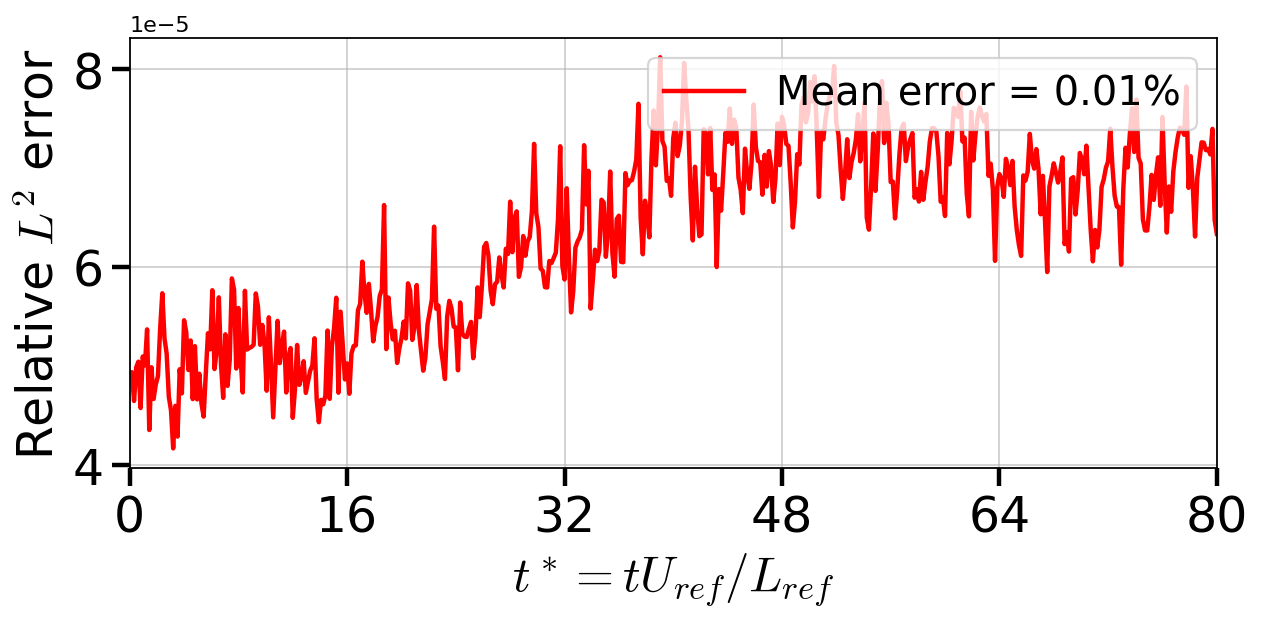

In [5]:
Re_target = 160

# True training snapshots
X_true = snapshot_dict[Re_target]   # (n_space, n_time)

# DMD reconstruction (flip to correct time direction)
X_dmd = dmd_dict[Re_target].reconstruction.detach().numpy()
X_dmd = X_dmd[:, ::-1]   

# Align spatial dimensions
min_dim = min(X_true.shape[0], X_dmd.shape[0])
X_true = X_true[:min_dim, :]
X_dmd  = X_dmd[:min_dim, :]

# Time vector (training)
times = np.array(sampled_times_dict[Re_target], dtype=float)
U_ref = U_ref_dict[Re_target]
time_nd = (times - times[0]) * U_ref / L_ref

# Compute error norms
abs_error = np.linalg.norm(X_true - X_dmd, axis=0)
rel_error = abs_error / np.linalg.norm(X_true, axis=0)

# Mean error in percent
mean_percent_error = 100 * np.mean(rel_error)

# Plot
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(time_nd, rel_error, 'r-', lw=2,
        label=f"Mean error = {mean_percent_error:.2f}%")

ax.set_xlabel(r"$t^* = t U_{ref}/L_{ref}$", fontsize=22)
ax.set_ylabel("Relative $L^2$ error", fontsize=22)


ax.grid(True, alpha=0.6)
ax.legend(fontsize = 18, loc="upper right")

ax.set_xlim(0, time_nd[-1])
ax.set_xticks(np.linspace(0, time_nd[-1], 6))
ax.tick_params(axis='both', which='major',
                   labelsize=22, length=8, width=2)
plt.tight_layout()
plt.show()


In [6]:
# Print the Vandermonde matrix structure
pt.vander(pt.tensor([2.0]), N=5)


tensor([[16.,  8.,  4.,  2.,  1.]])

## Step 3. Forecasting

 For each training parameter $\mu_j \in P = \{\mu_{\scriptstyle 1}, \mu_{\scriptstyle 2}, \dots, \mu_p\}
$ i.e., Reynolds numbers $Re$, the forecast snapshots at unseen time instants are $X_{\text{forecast}}^{(\mu_j)} \in \mathbb{R}^{n_{\text{space}} \times n_{\text{forecast}}}$
 $$X_{\text{forecast}}^{(\mu_j)}(t^\star) \;\; \text{with } t^\star \in \{t_1, t_2, \dots, t_{n_{\text{forecast}}}\}.
 $$ 

where  
- $\mu_j$ : $j$‑th training parameter in the set $P$  
- $n_{\text{space}}$ : number of spatial degrees of freedom  
- $n_{\text{forecast}}$ : number of forecast time instants  
- $t^\star$ : a specific forecast instant chosen from the forecast window (e.g., for comparison with true data)


In [7]:
forecast_dict = {}

n_steps = 500
times = np.array(sampled_times_dict[Re], dtype=float)
dt = times[1] - times[0]

for Re, dmd_model in dmd_dict.items():

    # Flow snapshots
    X_flow = snapshot_dict[Re]          # (n_space, n_time)

    # Cl snapshots
    cl = cl_train_dict[Re].reshape(1, -1)

    # Augmented state
    X_aug = np.vstack([X_flow, cl])     # (n_space + 1, n_time)

    # Initial condition = last augmented snapshot
    x0 = pt.tensor(X_aug[:, -1], dtype=pt.float32)

    # Forecast
    X_forecast = dmd_model.predict(x0, n_steps=n_steps).detach().cpu().numpy()

    # Time vector
    t0_forecast = float(sampled_times_dict[Re][-1])

    forecast_dict[Re] = {
        "t_forecast": t0_forecast + np.arange(n_steps + 1) * dt,
        "X_forecast": X_forecast,
        "cl_forecast": X_forecast[-1, :]   # last row = Cl
    }

    print(f"Re = {Re}: forecasted trajectory shape = {X_forecast.shape}")


Re = 100: forecasted trajectory shape = (11493, 501)
Re = 110: forecasted trajectory shape = (11493, 501)
Re = 120: forecasted trajectory shape = (11493, 501)
Re = 130: forecasted trajectory shape = (11493, 501)
Re = 140: forecasted trajectory shape = (11493, 501)
Re = 150: forecasted trajectory shape = (11493, 501)
Re = 160: forecasted trajectory shape = (11493, 501)
Re = 180: forecasted trajectory shape = (11493, 501)
Re = 190: forecasted trajectory shape = (11493, 501)
Re = 200: forecasted trajectory shape = (11493, 501)


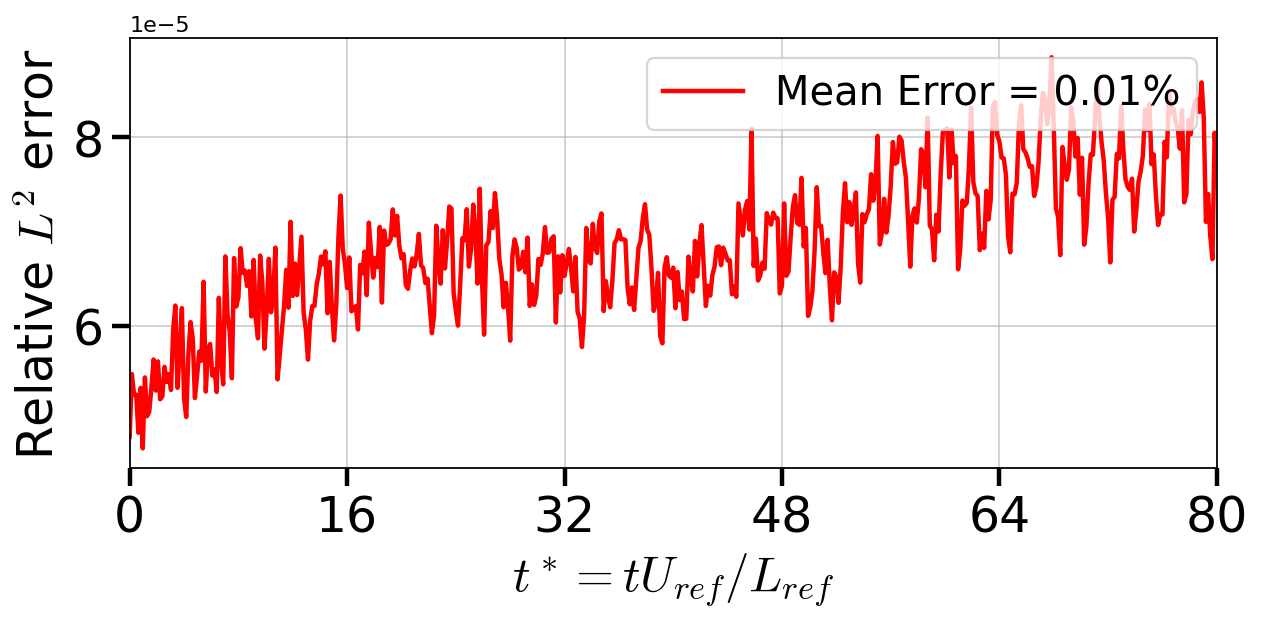

In [8]:
Re_target = 160

# Forecast results
X_forecast = forecast_dict[Re_target]["X_forecast"]
t_forecast = forecast_dict[Re_target]["t_forecast"]

# True snapshots (truncate to forecast horizon length)
X_true = snapshot_future_dict[Re_target][:, :X_forecast.shape[1]]

# Align spatial dimensions
min_dim = min(X_true.shape[0], X_forecast.shape[0])
X_true = X_true[:min_dim, :]
X_forecast = X_forecast[:min_dim, :]

# Non-dimensionalize time vector
U_ref = U_ref_dict[Re_target]
time_nd = (t_forecast - t_forecast[0]) * U_ref / L_ref

# Compute error norms
abs_error = np.linalg.norm(X_true - X_forecast, axis=0)
rel_error = abs_error / np.linalg.norm(X_true, axis=0)

# Mean error in percent
mean_percent_error = 100 * np.mean(rel_error)

# Plot error vs time
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(time_nd, rel_error, 'r-', lw=2,
        label=f"Mean Error = {mean_percent_error:.2f}%")

# Axis labels and title
ax.set_xlabel(r"$t^* = t U_{ref}/L_{ref}$", fontsize=22)
ax.set_ylabel("Relative $L^2$ error", fontsize=22)

# Grid and legend
ax.grid(True, alpha=0.6)
ax.legend(fontsize=18, loc="upper right")   

# Force x-axis to match data range and ticks
ax.set_xlim(0, time_nd[-1])
ax.set_xticks(np.linspace(0, time_nd[-1], 6))
ax.tick_params(axis='both', which='major',
                   labelsize=22, length=8, width=2)
plt.tight_layout()
plt.show()


## Step 4. Interpolation  

### Step 4.1.1 Mode importance sorting  
Modes are ranked using their **integral contribution** following Kou et al. (2017).  


#### Integral contribution-based sorting  
The integral contribution of mode $j$ at parameter $\mu$ is defined as:

$$
I_j^{(\mu)} \;=\; \big\|\phi_j^{(\mu)}\big\|_2^2 \;\cdot\; \sum_{k=1}^{N_s} \big| d_j(t_k;\mu) \big|
$$

- $I_j^{(\mu)}$: importance index of mode $j$ at parameter $\mu$  
- $\phi_j^{(\mu)}$: $j$‑th DMD mode vector at parameter $\mu$  
- $\|\cdot\|_2$: Euclidean norm (spatial energy of the mode)  
- $d_j(t_k;\mu)$: time‑dependent coefficient trajectory of mode $j$ at snapshot $k$ for parameter $\mu$  
- $N_s$: number of forecast snapshots  

**Reference:**  
Kou, J., Zhang, W., & Liu, H. (2017). *Dynamic mode decomposition with arbitrary sampling points*.  
European Journal of Mechanics - B/Fluids, 62, 45–55.  
DOI: [10.1016/j.euromechflu.2016.11.015](https://doi.org/10.1016/j.euromechflu.2016.11.015)  

### Step 4.1.2 Conjugate pair ordering  
Complex eigenvalues occur in conjugate pairs. To ensure consistency across parameters, pairs are ordered such that the eigenvalue with **positive imaginary part** precedes its conjugate with **negative imaginary part**.  

Formally, for each conjugate pair $(\lambda_j^{(\mu)}, \lambda_k^{(\mu)})$ with  

$$
\lambda_k^{(\mu)} \;=\; \overline{\lambda_j^{(\mu)}},
$$  

the ordering is defined as  

$$
\big( \lambda_j^{(\mu)}, \lambda_k^{(\mu)} \big) \quad \text{with} \quad \Im\!\left(\lambda_j^{(\mu)}\right) \;\geq\; 0.
$$  

The corresponding mode vectors and coefficients are permuted in the same way:  

$$
\big( \phi_j^{(\mu)}, \phi_k^{(\mu)} \big), 
\qquad
\big( d_j^{(\mu)}, d_k^{(\mu)} \big).
$$  

### Step 4.1.3 Phase alignment (MRPWI)  
Even after sorting and ordering, modes may differ by an arbitrary complex phase. To remove this ambiguity, each mode is **phase‑aligned** with a chosen reference case (e.g. the Reynolds number closest to the target).  

For mode $j$ at parameter $\mu$, the alignment factor is:  

$$
\theta_j^{(\mu)} \;=\; \arg \Big( \langle \phi_j^{(\mu)}, \phi_j^{(\mu_{\text{ref}})} \rangle \Big)
$$  

The aligned mode and its coefficients are then rotated by $\exp(-i \theta_j^{(\mu)})$, ensuring consistent phase across parameters.

In [9]:
from Flowtorch_DMD_cylinder_2D_modules.mode_eigs_prep import mode_eigs_prep

# Build raw modes / eigenvalues dicts from trained DMD models
modes_dict = {}
eigs_dict  = {}

for Re in Re_list:
    dmd = dmd_dict[int(Re)]
    modes_dict[Re] = dmd.modes.detach().cpu().numpy()        # (n_space+1, r_full)
    eigs_dict[Re]  = dmd.eigvals_cont.detach().cpu().numpy() # (r_full,)

# Preprocess: sort, pair conjugates, phase-align across Re
rank_prep = 30  # same as DMD rank

prep = mode_eigs_prep(
    parameter_list = Re_list,
    parameter_test = Re_test,
    modes_dict     = modes_dict,
    eigs_dict      = eigs_dict,
    rank           = rank_prep
)

prep.fit(
    dmd_dict = dmd_dict,
    integral = True,
    f_min    = -np.inf,
    f_max    = np.inf
)

# Extract aligned modes / eigenvalues and reference parameter
aligned_modes = prep.aligned_modes
aligned_eigs  = prep.aligned_eigs            # dicts keyed by Re
Re_ref = prep.param_ref                      # reference Re used for alignment

print("Reference Re for alignment:", Re_ref)
print("Aligned modes shape at Re_ref:", aligned_modes[Re_ref].shape)


Reference Re for alignment: 160
Aligned modes shape at Re_ref: (11493, 30)


/tmp/ipykernel_44174/1185903203.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16)


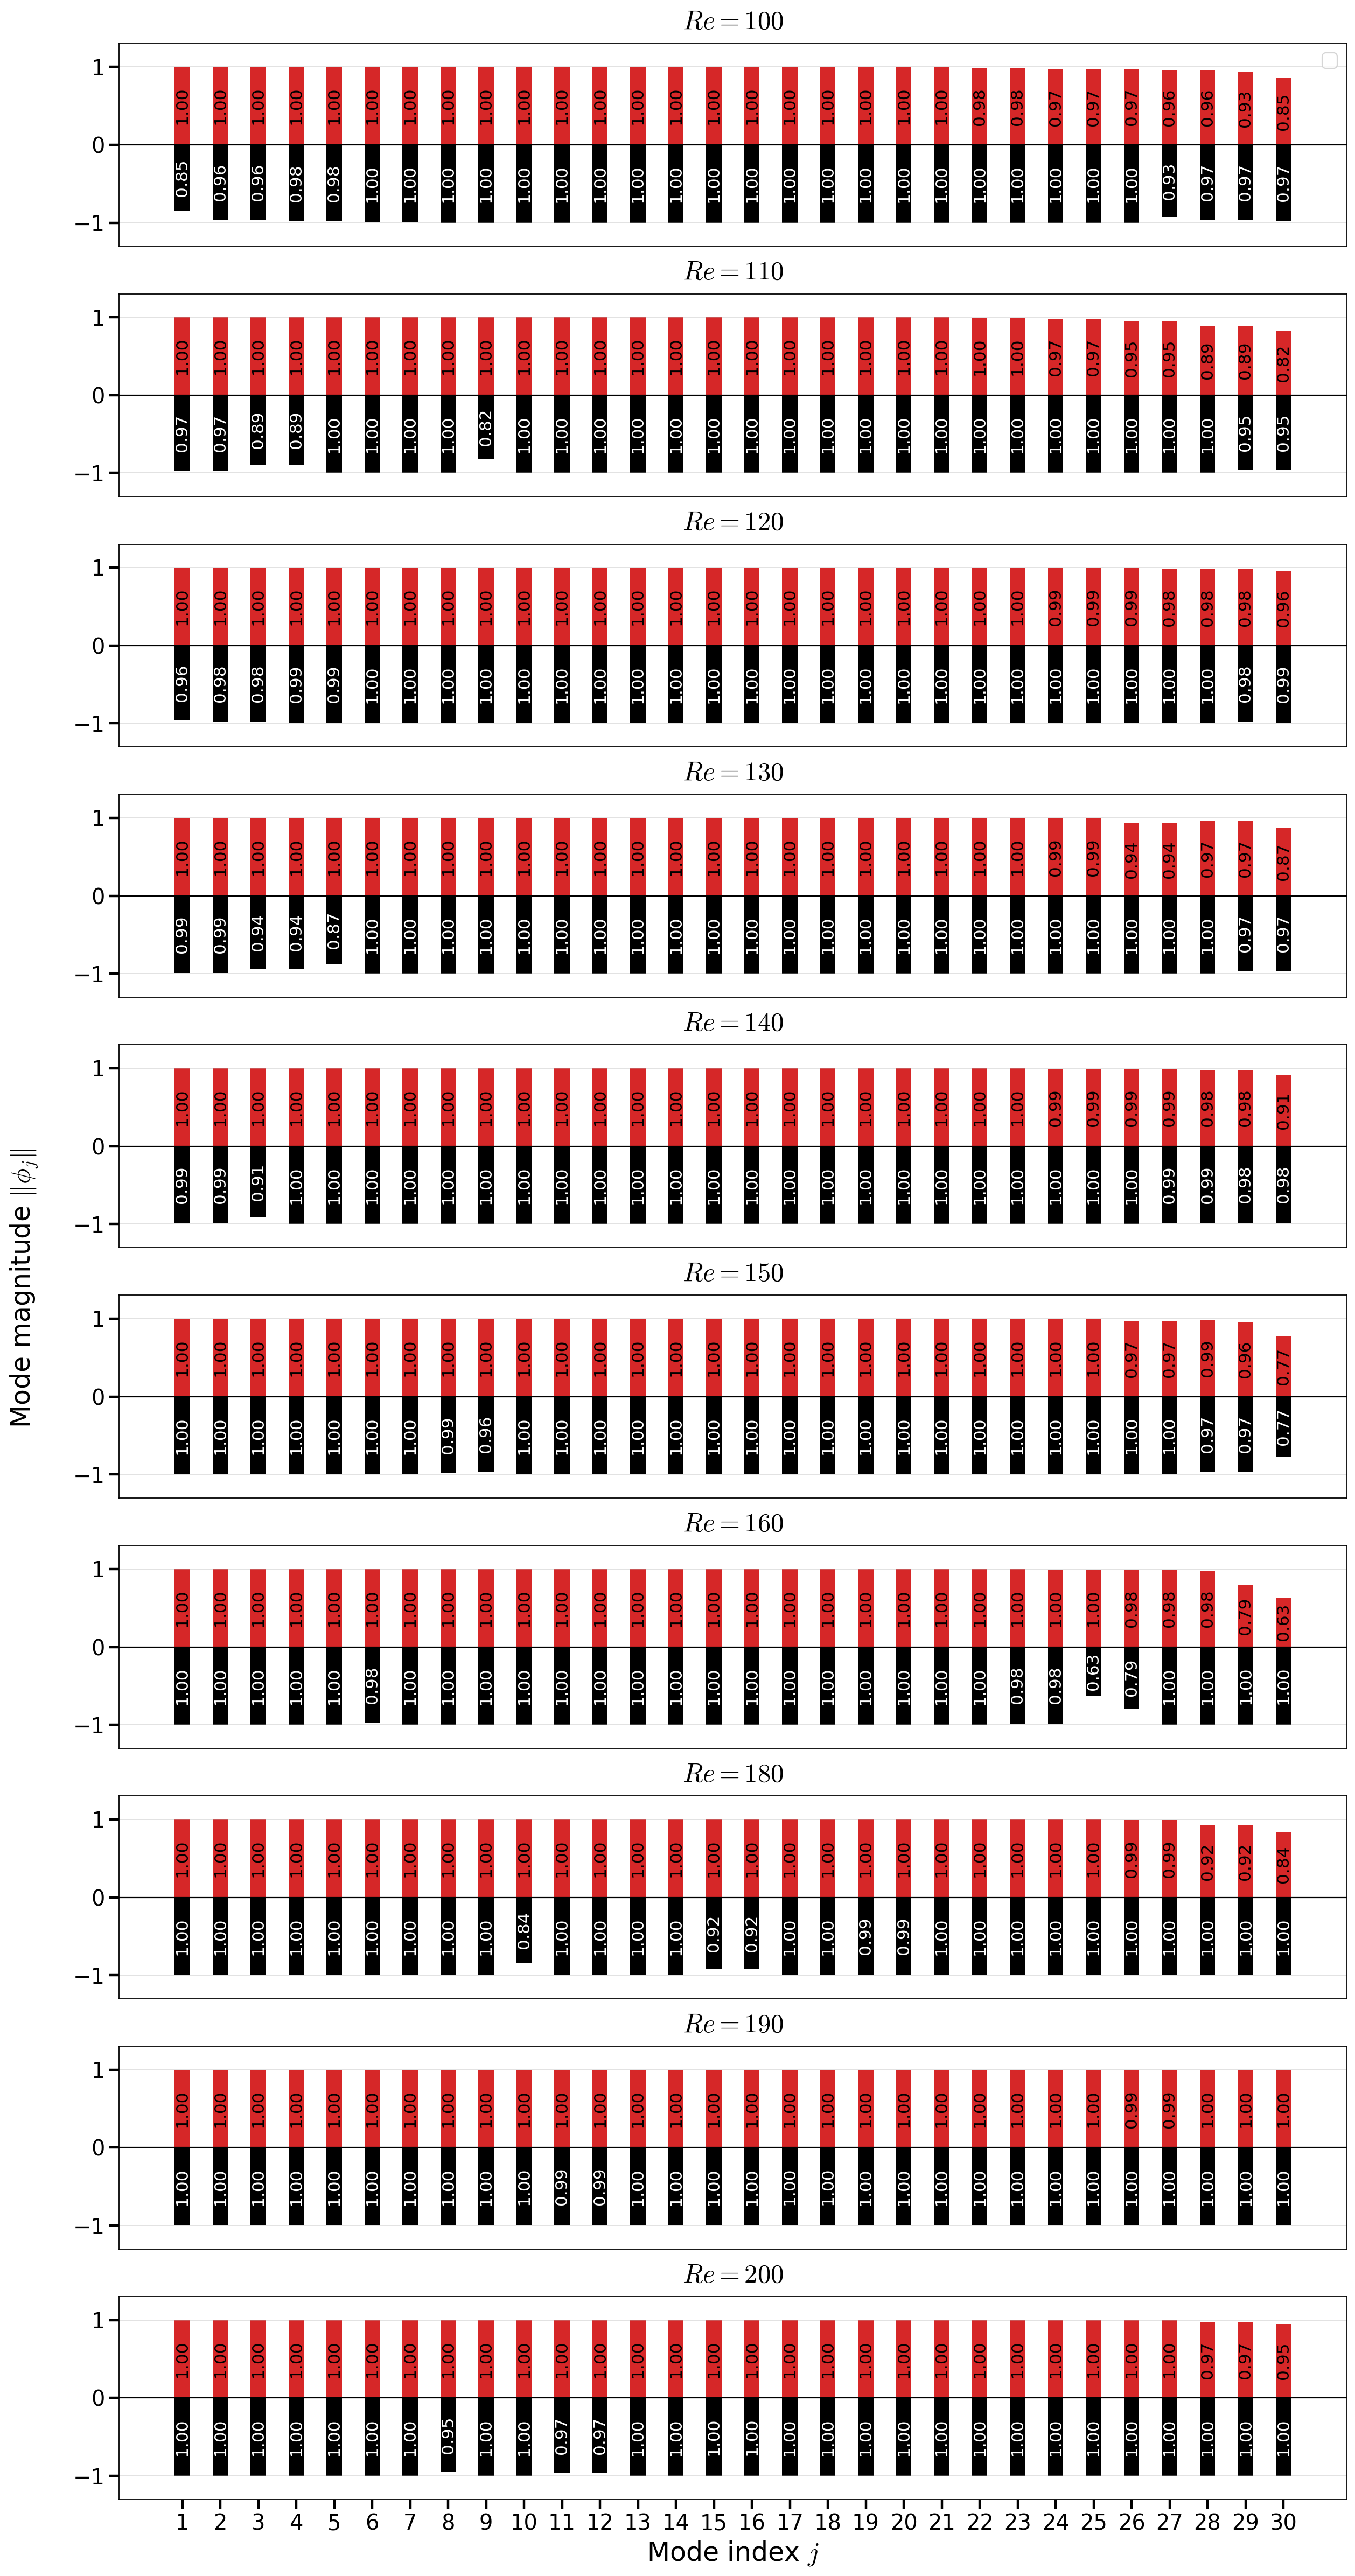

In [10]:
max_modes = 30
n = len(Re_list)
processed_modes_dict = prep.sorted_modes   # or paired_modes or aligned_modes

# REMOVE sharex=True
fig, axes = plt.subplots(n, 1, figsize=(16, 3*n))

for idx, Re in enumerate(Re_list):

    ax = axes[idx]

    Phi_raw = dmd_dict[Re].modes.detach().cpu().numpy()
    Phi_sorted = processed_modes_dict[Re]

    raw_mags    = np.linalg.norm(Phi_raw, axis=0)[:max_modes]
    sorted_mags = np.linalg.norm(Phi_sorted, axis=0)[:max_modes]

    m = len(sorted_mags)
    x = np.arange(m)

    # Sorted modes (upright)
    ax.bar(x, sorted_mags, width=0.4, color='tab:red')
    for j in range(m):
        ax.text(j, sorted_mags[j] * 0.5, f"{sorted_mags[j]:.2f}",
                ha='center', va='center',
                fontsize=14, rotation=90,
                color='black')  # stays black

    # Raw modes (inverted)
    ax.bar(x, -raw_mags, width=0.4, color='black')
    for j in range(m):
        ax.text(j, -raw_mags[j] * 0.5, f"{raw_mags[j]:.2f}",
                ha='center', va='center',
                fontsize=14, rotation=90,
                color='white')  

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f"$Re = {Re}$", fontsize=22, pad=12)
    ax.grid(True, axis='y', alpha=0.4)
    ax.margins(y=0.15)

    ax.tick_params(axis='both', which='major',
                   labelsize=18, length=8, width=2)

    # X‑ticks only on last subplot
    if idx == n - 1:
        ax.set_xticks(x)
        ax.set_xticklabels([str(j+1) for j in range(m)], fontsize=18)
    else:
        ax.set_xticks([])
        ax.set_xticklabels([])

    if idx == 0:
        ax.legend(fontsize=16)

axes[-1].set_xlabel("Mode index $j$", fontsize=22)

plt.tight_layout()
fig.subplots_adjust(left=0.10)
fig.text(0.02, 0.5, r"Mode magnitude $\|\phi_j\|$", va='center',
         rotation='vertical', fontsize=22)

plt.show()


In [11]:
# Plot sorting, pairing and alignment analysis
processed_modes_dict     = prep.paired_modes
selected_eigvals_dict    = prep.paired_eigs
selected_modes_dict      = prep.aligned_modes
Re_ref                   = prep.param_ref
top_k = rank_prep

# modes/eigs to inspect in detail
n_check = min(30, top_k)

print(" MODE SORTING, CONJUGATE PAIRING, AND ALIGNMENT")

for Re in Re_list:
    print("\n" + "="*90)
    print(f"REYNOLDS NUMBER Re = {Re}")
    print("="*90)

    # PROCESSED OBJECTS
    ordered_modes = processed_modes_dict[Re]
    ordered_eigs  = selected_eigvals_dict[Re]
    aligned_modes = selected_modes_dict[Re]

    print(f"Ordered modes shape:  {ordered_modes.shape}")
    print(f"Ordered eigvals shape:{ordered_eigs.shape}")
    print(f"Aligned modes shape:  {aligned_modes.shape}")

    # ORDERED EIGENVALUES (after ranking + pairing)
    print("\nFirst", n_check, "ordered eigenvalues (after ranking + pairing):")
    for j in range(n_check):
        print(f"  λ_ord[{j}] = {ordered_eigs[j]}")

    # CONJUGATE PAIRING CHECK
    print("\nConjugate pairing check for first", n_check, "ordered eigenvalues:")
    for j in range(n_check):
        eig = ordered_eigs[j]
        conj = np.conj(eig)
        matches = np.where(np.isclose(ordered_eigs, conj))[0]
        print(f"  λ_ord[{j}] = {eig}, conjugate indices ≈ {matches}")

    # PHASE ALIGNMENT CHECK
    Phi_ref = processed_modes_dict[Re_ref]

    print("\nPhase alignment check (inner products with reference) for first", n_check, "modes:")
    for k in range(n_check):
        phi_ref    = Phi_ref[:, k]
        phi_before = ordered_modes[:, k]
        phi_after  = aligned_modes[:, k]

        ip_before = np.vdot(phi_ref, phi_before)
        ip_after  = np.vdot(phi_ref, phi_after)

        angle_before = np.angle(ip_before)
        angle_after  = np.angle(ip_after)

        print(f"  Mode {k}:")
        print(f"    <ref, before> = {ip_before:.4e}, angle = {angle_before:.4f} rad")
        print(f"    <ref, after > = {ip_after:.4e}, angle = {angle_after:.4f} rad")


 MODE SORTING, CONJUGATE PAIRING, AND ALIGNMENT

REYNOLDS NUMBER Re = 100
Ordered modes shape:  (11493, 30)
Ordered eigvals shape:(30,)
Aligned modes shape:  (11493, 30)

First 30 ordered eigenvalues (after ranking + pairing):
  λ_ord[0] = (-1.3660763640737894e-07+0j)
  λ_ord[1] = (2.746559101177477e-06+16.7376655738305j)
  λ_ord[2] = (2.746559101177477e-06-16.7376655738305j)
  λ_ord[3] = (-1.975346505359285e-06+33.475331326425724j)
  λ_ord[4] = (-1.975346505359285e-06-33.475331326425724j)
  λ_ord[5] = (1.9741188353402492e-05+50.21300235680995j)
  λ_ord[6] = (1.9741188353402492e-05-50.21300235680995j)
  λ_ord[7] = (3.9356488524753766e-05+66.95069353748643j)
  λ_ord[8] = (3.9356488524753766e-05-66.95069353748643j)
  λ_ord[9] = (3.310080632784964e-05+83.68833808309589j)
  λ_ord[10] = (3.310080632784964e-05-83.68833808309589j)
  λ_ord[11] = (7.749745758406097e-05+100.4260981701911j)
  λ_ord[12] = (7.749745758406097e-05-100.4260981701911j)
  λ_ord[13] = (3.867870345596188e-05+117.163732287

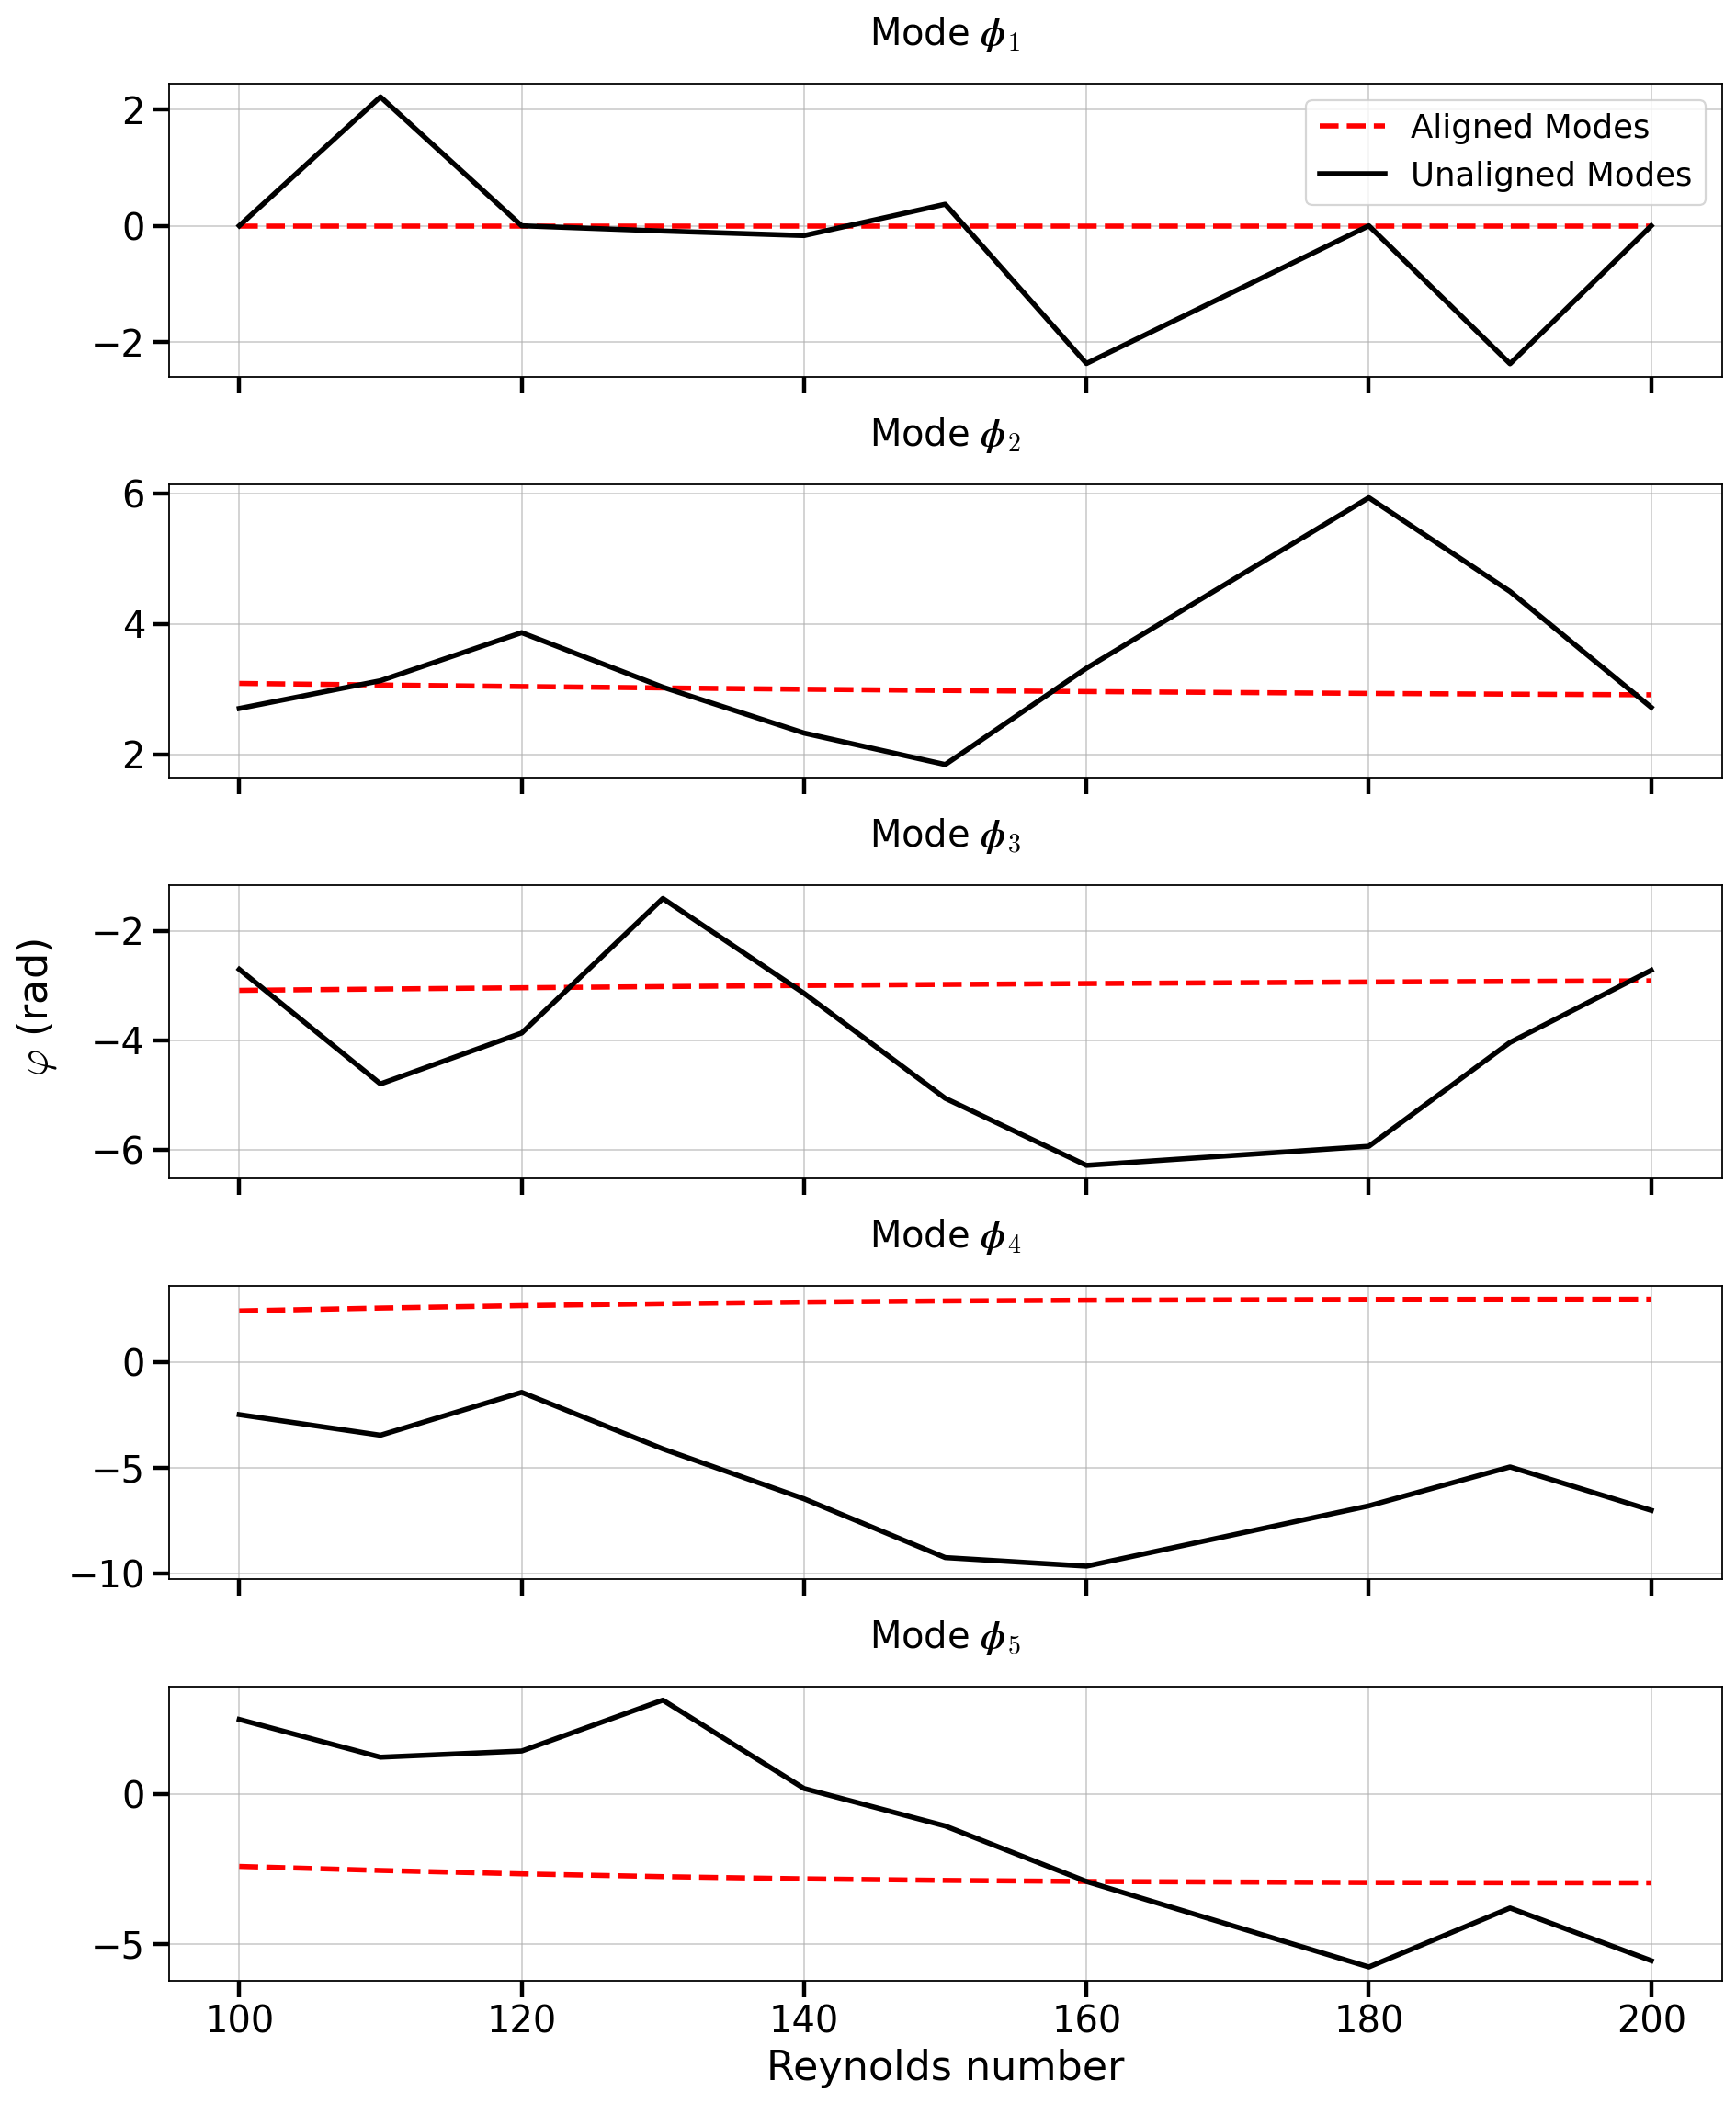

In [12]:
# Plot modal phases across parameters 
num_modes = 5

# USE ALIGNED reference, not paired
Phi_ref = selected_modes_dict[160]
ref_idx = [np.argmax(np.abs(Phi_ref[:, j])) for j in range(num_modes)]

phase_aligned   = {j: [] for j in range(num_modes)}
phase_unaligned = {j: [] for j in range(num_modes)}

for Re in Re_list:

    PhiA = selected_modes_dict[Re]                     # aligned
    PhiU = dmd_dict[Re].modes.detach().cpu().numpy()  # raw

    for j in range(num_modes):
        idx = ref_idx[j]

        phase_aligned[j].append(np.angle(PhiA[idx, j]))
        phase_unaligned[j].append(np.angle(PhiU[idx, j]))

# unwrap phases
for j in range(num_modes):
    phase_aligned[j]   = np.unwrap(phase_aligned[j])
    phase_unaligned[j] = np.unwrap(phase_unaligned[j])

# plot
fig, axes = plt.subplots(num_modes, 1, figsize=(12, 3*num_modes), sharex=True)

for j in range(num_modes):
    ax = axes[j]

    ax.plot(Re_list, phase_aligned[j], 'r--', linewidth=2.5, label="Aligned Modes")
    ax.plot(Re_list, phase_unaligned[j], 'k-', linewidth=2.5, label="Unaligned Modes")

    ax.text(
        0.5, 1.10,
        rf"Mode $\boldsymbol{{\phi}}_{j+1}$",
        transform=ax.transAxes,
        fontsize=18,
        va='bottom',
        ha='center'
    )

    ax.tick_params(axis='both', which='major',
                   labelsize=18, length=8, width=2)

    ax.grid(alpha=0.6)

    if j == 0:
        ax.legend(fontsize=16, loc="upper right")

fig.supylabel(r"$\varphi$ (rad)", fontsize=20, x=0.02)
axes[-1].set_xlabel("Reynolds number", fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [13]:


fund_idx = 1  # index of fundamental mode after your sorting

Re_vals = sorted(Re_list)
f_vals  = []

for Re in Re_vals:
    lam = selected_eigvals_dict[Re][fund_idx]
    f   = abs(lam.imag) / (2*np.pi)
    f_vals.append(f)
    print(f"Re={Re}, f={f:.3f} Hz")


Re=100, f=2.664 Hz
Re=110, f=2.947 Hz
Re=120, f=3.227 Hz
Re=130, f=3.505 Hz
Re=140, f=3.782 Hz
Re=150, f=4.058 Hz
Re=160, f=4.334 Hz
Re=180, f=4.888 Hz
Re=190, f=5.165 Hz
Re=200, f=5.445 Hz


In [14]:
from Flowtorch_DMD_cylinder_2D_modules.lagrange_interp import lagrange_interp



aligned_modes = prep.aligned_modes   # this one you just printed as 2D
aligned_eigs  = prep.aligned_eigs

interp = lagrange_interp(
    parameter_list = Re_list,
    parameter_test = Re_test,
    aligned_modes  = aligned_modes,
    aligned_eigs   = aligned_eigs,
    x_0            = {},
    stencil_sizes  = [2, 4, 6],
    interp_x0      = False
)

interp.fit()


## Step 4.5. Lagrange interpolation of the true initial condition $x_0$ at $\mu^*$

Instead of interpolating modal amplitudes or projecting onto a modal basis, 
the initial condition at the target parameter $\mu^*$ (i.e., Reynolds number) 
is obtained by interpolating the *true* initial conditions from the stencil 
parameters using Lagrange polynomials:


$$
x_0^{(\mu^*)}
=
\sum_{i=1}^{N_p}
L_i(\mu^*) \, x_0^{(\mu_i)},
$$

- $x_0^{(\mu^*)}$ : interpolated initial condition at the target parameter  
- $x_0^{(\mu_i)}$ : true initial condition at stencil parameter $\mu_i$  
- $L_i(\mu^*)$ : Lagrange basis polynomial associated with $\mu_i$


## Step 4.6. Interpoled trajectory reconstruction

Reconstruct the interpolated trajectory for the target parameter $\mu^*$ as: 



$$
X_{\text{interp}}^{(\mu^*)}(t) = \phi^{(\mu^*)} 
\left( b^{(\mu^*)} \odot e^{s^{(\mu^*)} t} \right)
$$




where  
- $\phi^{(\mu^*)} \in \mathbb{C}^{n_{\text{space}} \times r}$ : interpolated DMD modes  
- $s^{(\mu^*)} \in \mathbb{C}^r$ : interpolated eigenvalues  
- $b^{(\mu^*)} \in \mathbb{C}^r$ : interpolated amplitudes  
- $t$ : forecast time instants  


In [15]:
# Step 4.5. Initial condition x_0 at test parameter μ*

# Build augmented initial conditions x_0(Re) for all training Reynolds numbers.
# Each x₀(Re) contains:
#   - the final flow snapshot at that Re
#   - the final lift coefficient value at that Re
x0_true_dict = {}
for Re in Re_list:
    x_flow = snapshot_dict[Re][:, -1]      # final flow field snapshot at Re
    x_cl   = cl_train_dict[Re][-1]         # final Cl value at Re
    x0_true_dict[Re] = np.hstack([x_flow, x_cl])   # augmented state vector

# Identify the closest neighbor Reynolds number μ_j closest to μ*.
# The 2‑point stencil is sorted by proximity, so index 0 is the closest.
stencil_sets = interp.stencils
closest_Re = stencil_sets[2][0]

# Extract the augmented initial condition x_0 from that closest neighbor used for reconstruction at μ*.
neighbor_x0 = x0_true_dict[closest_Re]


In [16]:
# Choose reconstruction rank
r_recon = 30      

recon_results_aligned = {}

# Spatial dimension of the augmented state 
n_space = forecast_dict[Re_list[0]]["X_forecast"].shape[0]

# Flow dimension exclude Cl
n_flow = n_space - 1
half   = n_flow // 2
# Extract interpolated modes and eigenvalues from the interpolator
interp_modes_aligned   = interp.interp_modes

interp_eigs_aligned    = interp.interp_eigs


# Time vector for reconstruction
t_vec = np.array(forecast_dict[Re_list[0]]["t_forecast"], dtype=float)
t0 = t_vec[0]

# Loop over stencil sizes
for Np in stencil_sets.keys():

    # Φ^(μ*): interpolated modes at target Reynolds
    Phi_full = interp_modes_aligned[Np]          # (n_space × r_full)

    # Truncate to selected rank
    Phi = Phi_full[:, :r_recon]                  # (n_space × r_recon)

    # s^(μ*): interpolated continuous-time eigenvalues
    s_full = interp_eigs_aligned[Np]             # (r_full,)
    s      = s_full[:r_recon]                    # (r_recon,)

    # x0^(μ*): initial condition from closest neighbor
    x_0 = neighbor_x0                            # (n_space,)

    # Φ†: pseudoinverse
    Phi_pinv = np.linalg.pinv(Phi)               # (r_recon × n_space)

    # Allocate reconstruction array
    X_recon = np.zeros((n_space, len(t_vec)), dtype=complex)

    # Reconstruction loop
    for k, t in enumerate(t_vec):
        expS = np.exp(s * (t - t0))              # (r_recon,)
        X_recon[:, k] = Phi @ (expS * (Phi_pinv @ x_0))

    # Store result
    recon_results_aligned[Np] = X_recon


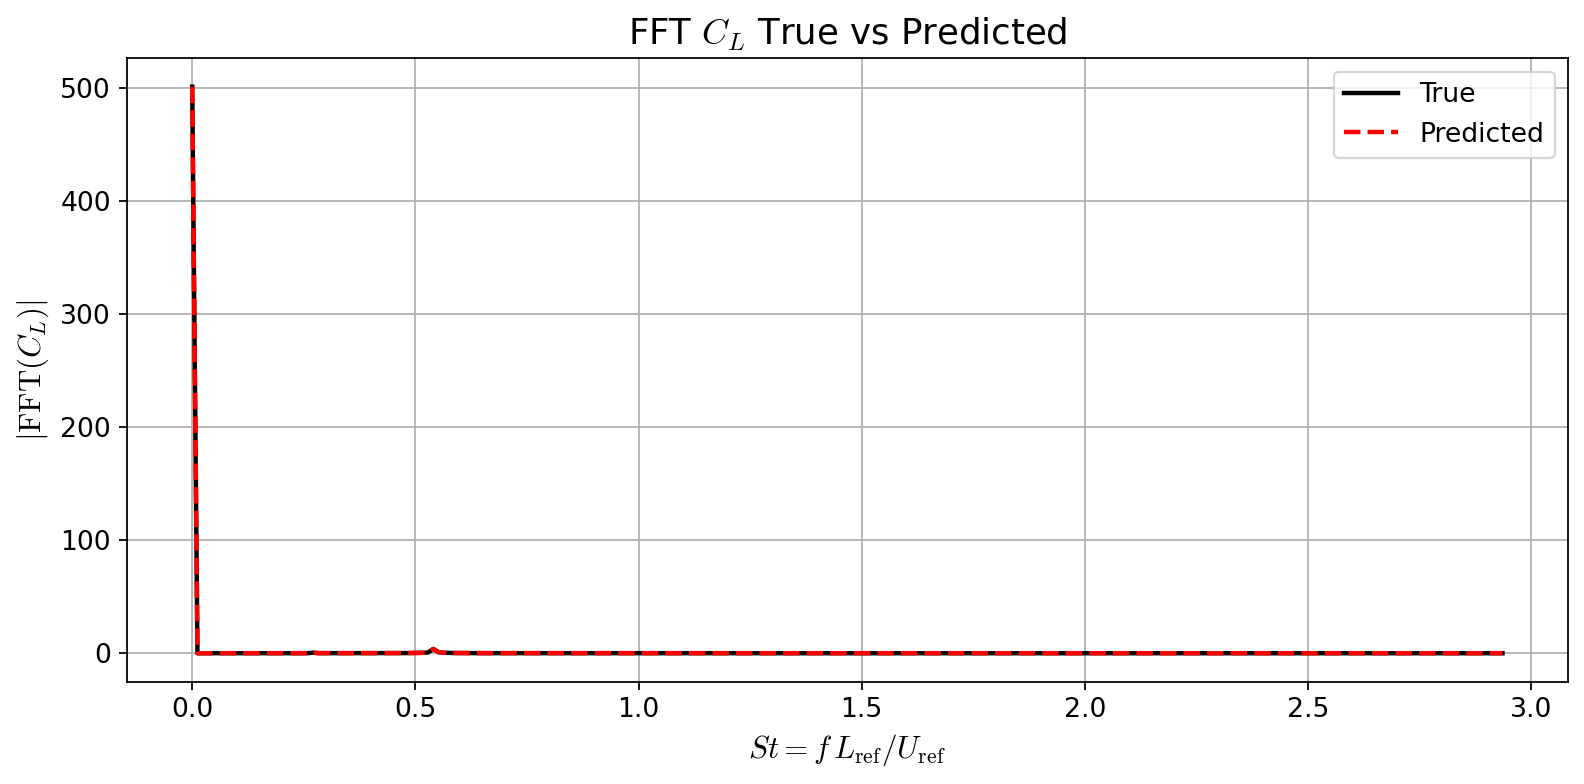

In [21]:
# Extract reconstructed Cl(t) from augmented DMD state
Np = 2   # or 4 or 6


# Extract true Cl(t) from test case
Cl_true  = np.real(cl_test)
t_true   = np.array(cl_test_times, float)

X_recon = recon_results_aligned[Np]
Cl_recon = np.real(X_recon[-1, :])


# Ensure time vectors match
if len(Cl_true) != len(Cl_recon):
    Cl_true = np.interp(t_vec, t_true, Cl_true)
    t_true  = t_vec.copy()

# FFT parameters
dt = t_true[1] - t_true[0]
freqs = np.fft.rfftfreq(len(Cl_true), d=dt)

# Non-dimensional frequency 
St = freqs * L_ref / U_ref_test


# Compute FFT magnitudes
fft_true  = np.abs(np.fft.rfft(Cl_true))
fft_recon = np.abs(np.fft.rfft(Cl_recon))

# RMS normalization (non-dimensional amplitude) 
Cl_true_rms  = np.sqrt(np.mean(Cl_true**2))
Cl_recon_rms = np.sqrt(np.mean(Cl_recon**2))

fft_true_nd  = fft_true  / Cl_true_rms
fft_recon_nd = fft_recon / Cl_recon_rms

# Plot FFT comparison (non-dimensional)
plt.figure(figsize=(10,5))
plt.plot(St, fft_true_nd,  label="True ", linewidth=2,color="black")
plt.plot(St, fft_recon_nd, label="Predicted", linestyle='--', linewidth=2, color="red")

plt.xlabel(r"$St = f\,L_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=14)
plt.ylabel(r"$|\mathrm{FFT}(C_L)|$", fontsize=14)
plt.title(r"FFT $C_L$ True vs Predicted", fontsize=16)

plt.grid(True, which='both')
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


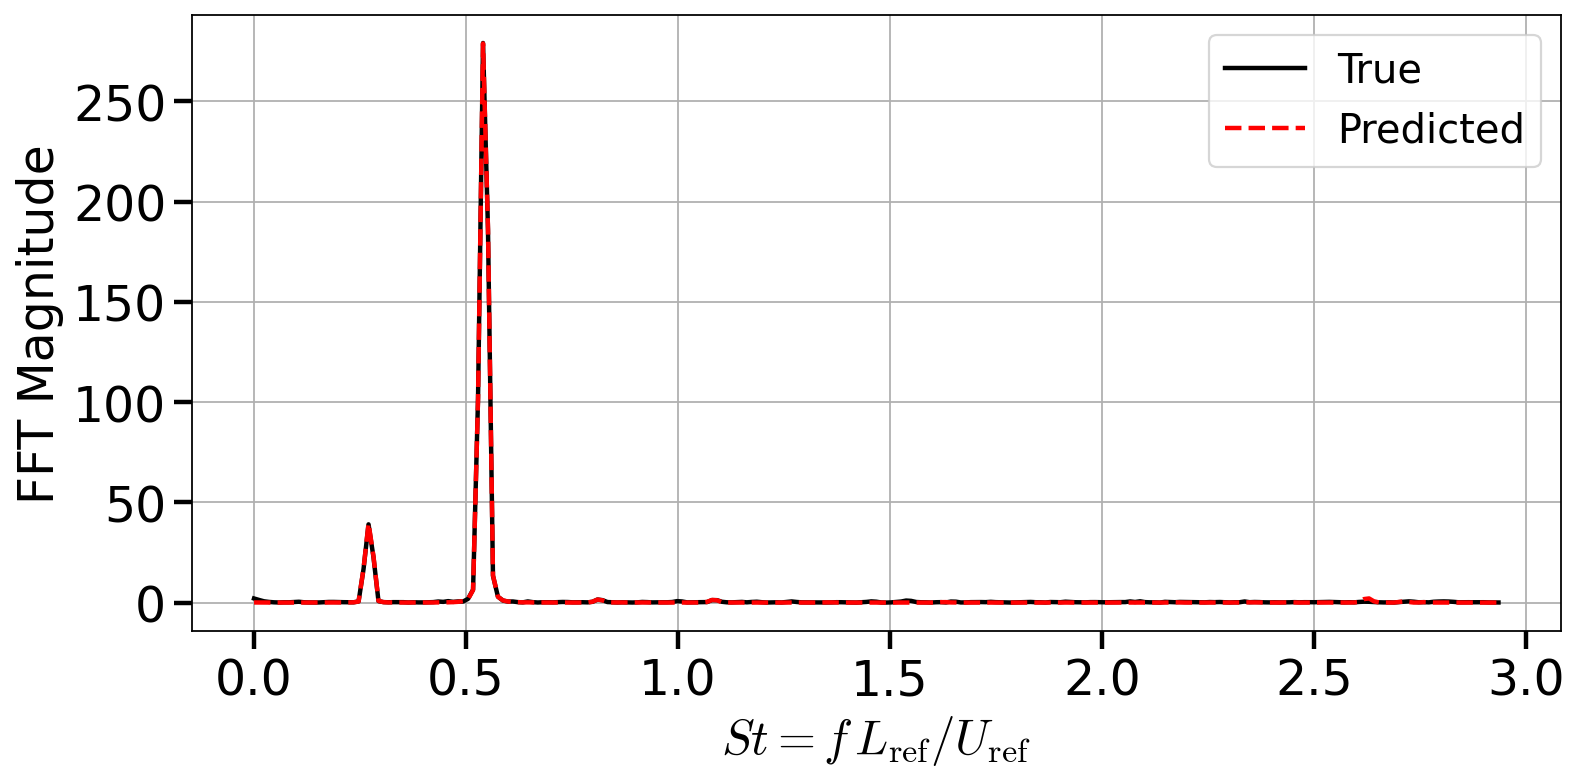

In [22]:


# Remove mean
Cl_true_d  = Cl_true  - Cl_true.mean()
Cl_recon_d = Cl_recon - Cl_recon.mean()

# Apply Hann window
window = np.hanning(len(Cl_true))
Cl_true_w  = Cl_true_d  * window
Cl_recon_w = Cl_recon_d * window

# FFT (windowed)
fft_true  = np.abs(np.fft.rfft(Cl_true_w))
fft_recon = np.abs(np.fft.rfft(Cl_recon_w))

# Non-dimensional frequency (same St as before)
St = freqs * L_ref / U_ref_test

# RMS normalization
Cl_true_rms_w  = np.sqrt(np.mean(Cl_true_w**2))
Cl_recon_rms_w = np.sqrt(np.mean(Cl_recon_w**2))

fft_true_nd_w  = fft_true  / Cl_true_rms_w
fft_recon_nd_w = fft_recon / Cl_recon_rms_w

# Plot on log scale (non-dimensional)
plt.figure(figsize=(10,5))
plt.plot(St, fft_true_nd_w,  label="True", linewidth=2, color="black")
plt.plot(St, fft_recon_nd_w, label="Predicted", linestyle='--', linewidth=2, color="red")

plt.xlabel(r"$St = f\,L_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=22)
plt.ylabel(r"FFT Magnitude", fontsize=22)

plt.grid(True, which='both')
plt.legend(fontsize=18)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.tick_params(axis='both', which='major', length=8, width=2)

plt.tight_layout()
plt.show()


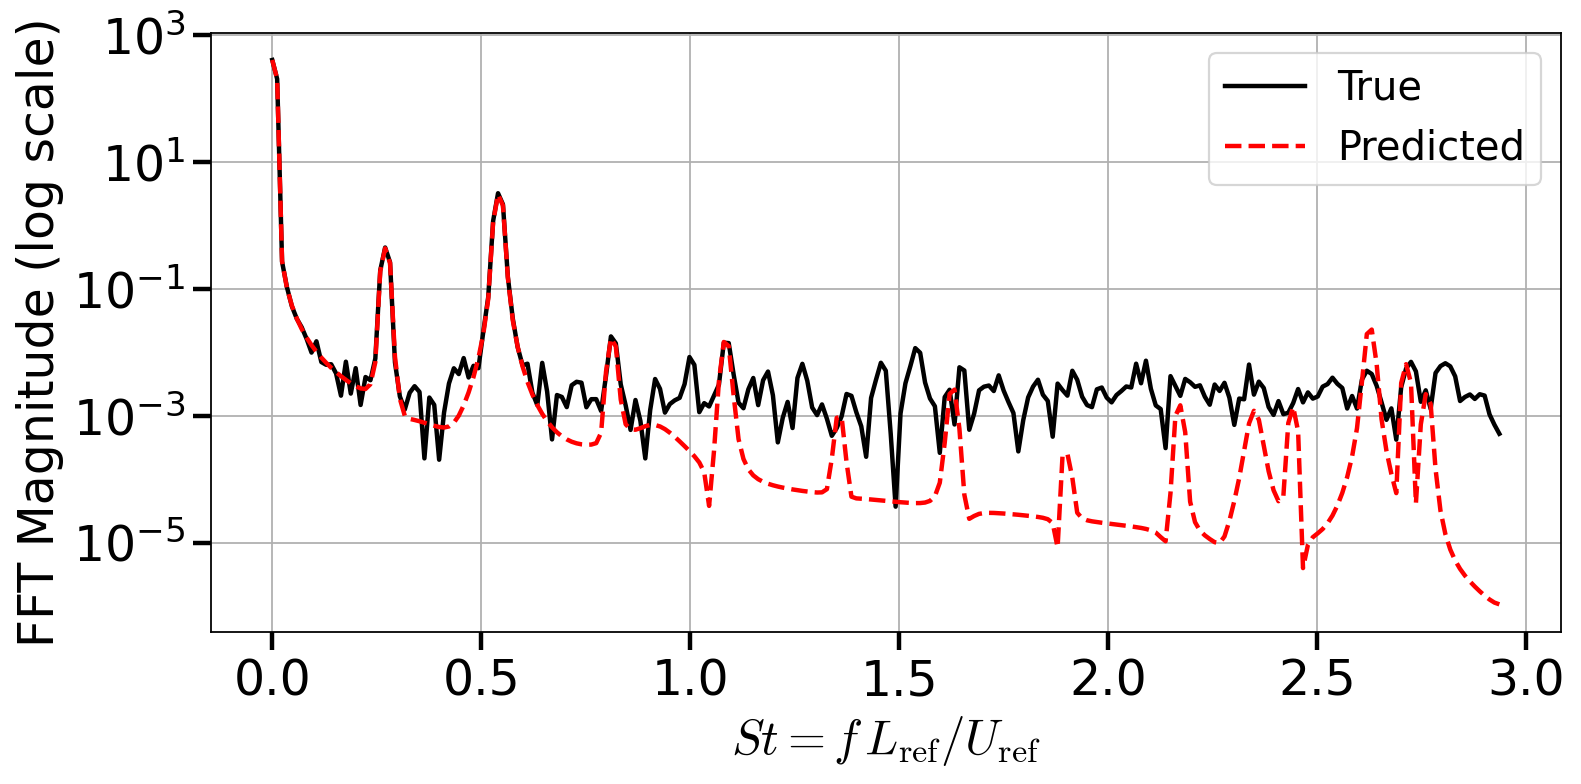

In [23]:
# FFT of true vs predicted C_l on log scale (non-dimensional)

# Apply Hann window
Cl_true_w  = Cl_true  * np.hanning(len(Cl_true))
Cl_recon_w = Cl_recon * np.hanning(len(Cl_recon))

# FFT
fft_true  = np.abs(np.fft.rfft(Cl_true_w))
fft_recon = np.abs(np.fft.rfft(Cl_recon_w))

# Non-dimensional frequency
St = freqs * L_ref / U_ref_test

# RMS normalization
Cl_true_rms_w  = np.sqrt(np.mean(Cl_true_w**2))
Cl_recon_rms_w = np.sqrt(np.mean(Cl_recon_w**2))

fft_true_nd_w  = fft_true  / Cl_true_rms_w
fft_recon_nd_w = fft_recon / Cl_recon_rms_w

# Plot on log scale
plt.figure(figsize=(10,5))
plt.plot(St, fft_true_nd_w,  label="True", linewidth=2, color="black")
plt.plot(St, fft_recon_nd_w, label="Predicted", linestyle='--', linewidth=2, color="red")

plt.yscale("log")
plt.xlabel(r"$St = f\,L_{\mathrm{ref}} / U_{\mathrm{ref}}$", fontsize=22)
plt.ylabel(r"FFT Magnitude (log scale)", fontsize=22)

plt.grid(True, which='both')
plt.legend(fontsize=18)

plt.xticks(fontsize=22)
plt.yticks(fontsize=22)

plt.tick_params(axis='both', which='major', length=8, width=2)

plt.tight_layout()
plt.show()


Best lag (samples): 2
Best lag (seconds): 0.020000


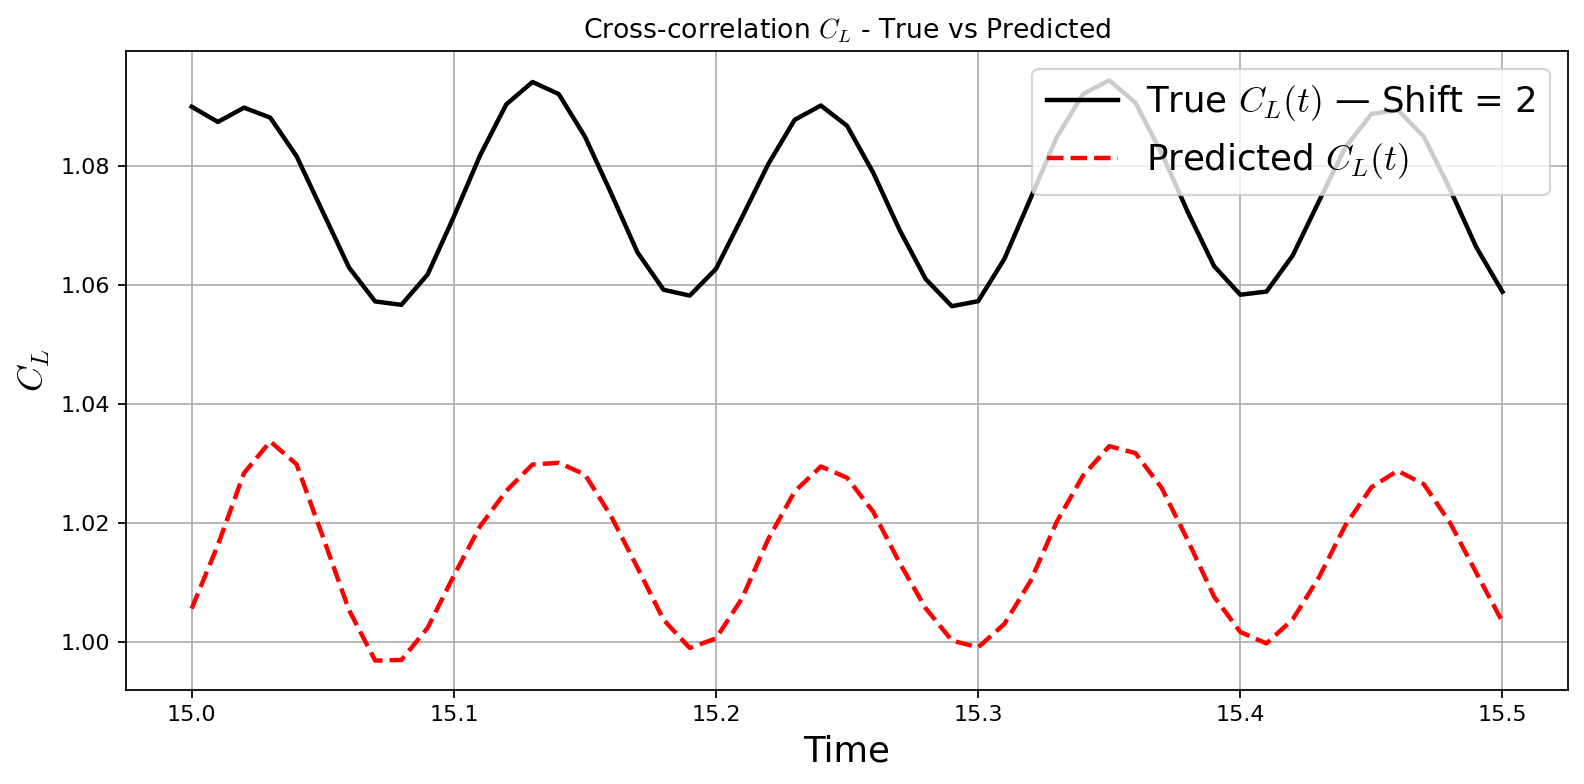

In [24]:
# True Cl(t) from test data
Cl_true = np.real(cl_test)
t_true  = np.array(cl_test_times, float)

# Reconstructed Cl(t) from aligned DMD
Np = 2   # choose stencil size
X_recon = recon_results_aligned[Np]
Cl_recon = np.real(X_recon[-1, :])
t_recon  = t_vec.copy()

# Align time vectors if needed
if len(Cl_true) != len(Cl_recon):
    Cl_true = np.interp(t_recon, t_true, Cl_true)
    t_true  = t_recon.copy()

dt = t_true[1] - t_true[0]

# Detrend both signals
Cl_true_d  = Cl_true  - np.mean(Cl_true)
Cl_recon_d = Cl_recon - np.mean(Cl_recon)

# Cross-correlation for phase alignment
corr = np.correlate(Cl_recon_d, Cl_true_d, mode='full')
lags = np.arange(-len(Cl_true_d) + 1, len(Cl_recon_d))

best_idx = np.argmax(corr)
best_lag = lags[best_idx]

# Shift TRUE signal to best match reconstructed
Cl_true_shifted = np.roll(Cl_true, best_lag)

print(f"Best lag (samples): {best_lag}")
print(f"Best lag (seconds): {best_lag * dt:.6f}")

# Zoomed plot
zoom_start = t_true[0]
zoom_end   = t_true[0] + 0.5
mask = (t_true >= zoom_start) & (t_true <= zoom_end)

plt.figure(figsize=(10,5))
plt.plot(t_true[mask], Cl_true_shifted[mask], label=f"True $C_L(t)$ — Shift = {best_lag}", linewidth=2, color="black")
plt.plot(t_recon[mask], Cl_recon[mask], '--', label="Predicted $C_L(t)$", linewidth=2, color="red")
plt.xlabel("Time", fontsize=16)
plt.ylabel("$C_L$", fontsize=16)
plt.title("Cross-correlation $C_L$ - True vs Predicted")
plt.legend(loc="upper right",fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


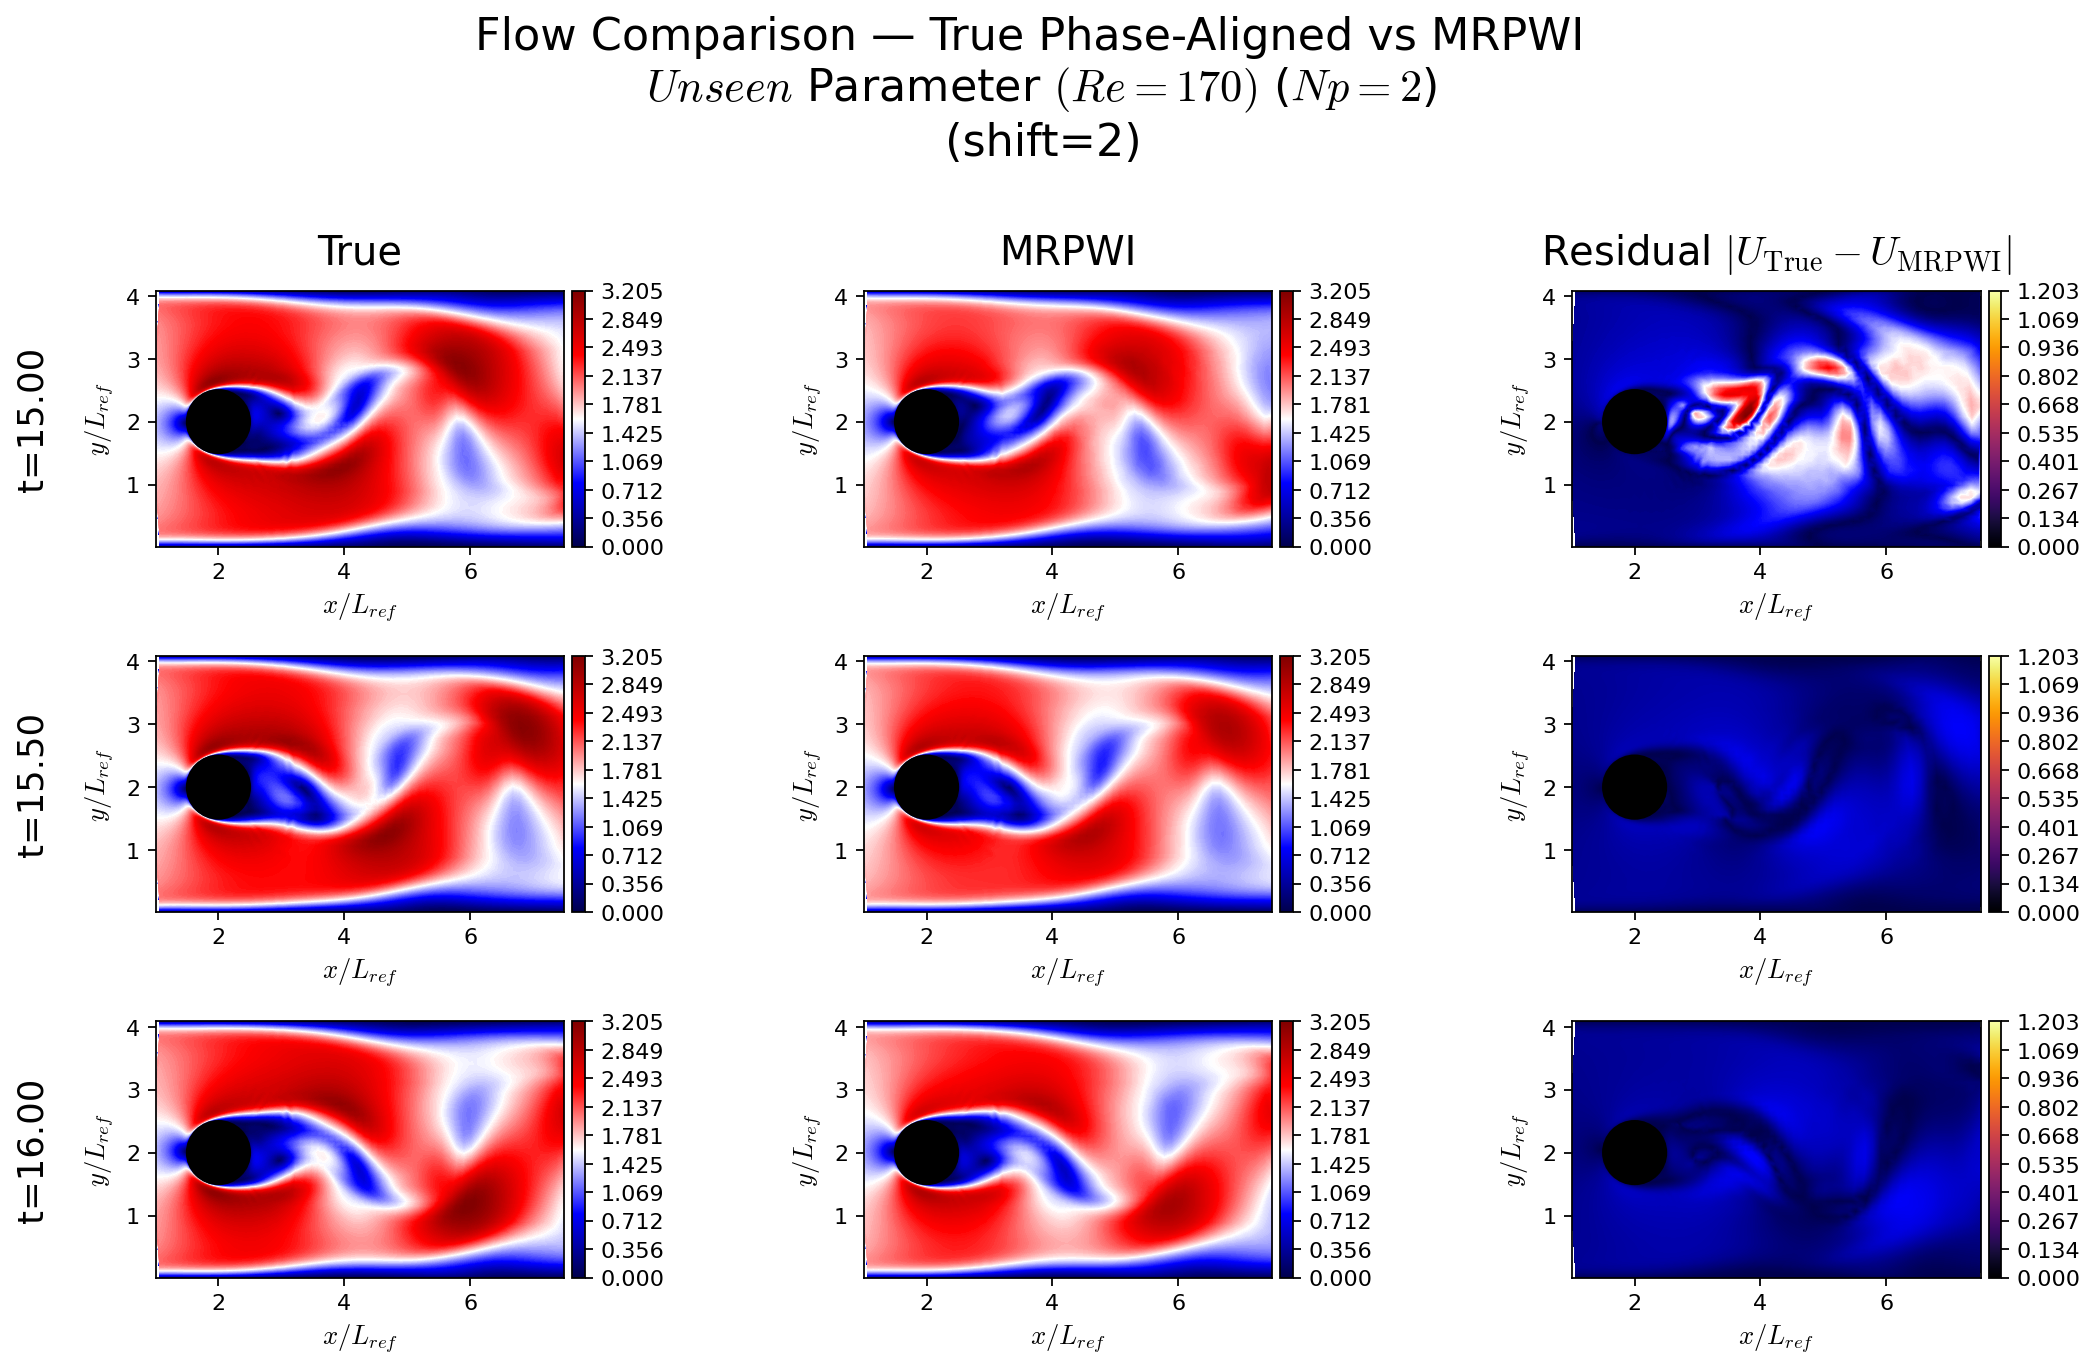

In [25]:
# Flow Comparison — Phase-Aligned TRUE vs MRPWI
from mpl_toolkits.axes_grid1 import make_axes_locatable

# FLOW-ONLY TRUE SNAPSHOTS (phase-aligned)
manual_shift = best_lag
X_true_raw = snapshot_test_future[:, :len(t_vec)]
X_true_aligned = np.roll(X_true_raw, shift=manual_shift, axis=1)

# TIME WINDOW SELECTION
t_start, t_end = 15.0, 16.0
granularity = 50
Np_vis = 2   # stencil to visualize

time_vec = np.array(sampled_times_test_future, dtype=float)
mask     = (time_vec >= t_start) & (time_vec <= t_end)
indices  = np.where(mask)[0][::granularity]

# GEOMETRY
coords = coords_test / L_ref
x_flat, y_flat = coords[:, 0], coords[:, 1]
tri = mtri.Triangulation(x_flat, y_flat)

# RECONSTRUCTION
X_recon = recon_results_aligned[Np_vis]

# PRECOMPUTE MAGNITUDES
aligned_mags = []
recon_mags   = []
resid_mags   = []

for i in indices:
    ux_a = np.real(X_true_aligned[:half, i])
    uy_a = np.real(X_true_aligned[half:n_flow, i])
    mag_a = np.sqrt(ux_a**2 + uy_a**2)

    ux_r = np.real(X_recon[:half, i])
    uy_r = np.real(X_recon[half:n_flow, i])
    mag_r = np.sqrt(ux_r**2 + uy_r**2)

    mag_resid = np.abs(mag_a - mag_r)

    aligned_mags.append(mag_a)
    recon_mags.append(mag_r)
    resid_mags.append(mag_resid)

# COLOR LIMITS
vmin = min(m.min() for m in aligned_mags + recon_mags)
vmax = max(m.max() for m in aligned_mags + recon_mags)
norm = Normalize(vmin=vmin, vmax=vmax)
sm   = ScalarMappable(norm=norm, cmap="seismic"); sm.set_array([])

vmin_r = 0.0
vmax_r = max(m.max() for m in resid_mags)
norm_r = Normalize(vmin=vmin_r, vmax=vmax_r)
sm_r   = ScalarMappable(norm=norm_r, cmap="inferno"); sm_r.set_array([])

fixed_ticks_main  = np.linspace(vmin,   vmax,   10)
fixed_ticks_resid = np.linspace(vmin_r, vmax_r, 10)

# === EXACT SAME LAYOUT AS REFERENCE ===
num_rows = len(indices)
fig, axes = plt.subplots(num_rows, 3, figsize=(14, 3 * num_rows))

fig.suptitle(
    f"Flow Comparison — True Phase-Aligned vs MRPWI \n $Unseen$ Parameter $(Re={Re_test})$ ($Np={Np_vis}$) \n (shift={manual_shift})",
    fontsize=20, y=0.97
)

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row, i in enumerate(indices):
    t_val = time_vec[i]

    # TRUE aligned
    ax_true = axes[row, 0]
    ax_true.tricontourf(tri, aligned_mags[row], levels=200, cmap="seismic",
                        vmin=vmin, vmax=vmax)
    ax_true.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref),
                             radius/L_ref, color="black", zorder=10))
    ax_true.set_aspect("equal")

    divider = make_axes_locatable(ax_true)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    fig.colorbar(sm, cax=cax, ticks=fixed_ticks_main)

    ax_true.text(-0.30, 0.5, f"t={t_val:.2f}",
                 transform=ax_true.transAxes,
                 fontsize=16, rotation=90,
                 va="center", ha="center",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

    # MRPWI Reconstruction
    ax_recon = axes[row, 1]
    ax_recon.tricontourf(tri, recon_mags[row], levels=200, cmap="seismic",
                         vmin=vmin, vmax=vmax)
    ax_recon.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref),
                              radius/L_ref, color="black", zorder=10))
    ax_recon.set_aspect("equal")

    divider = make_axes_locatable(ax_recon)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    fig.colorbar(sm, cax=cax, ticks=fixed_ticks_main)

    # Residual
    ax_res = axes[row, 2]
    ax_res.tricontourf(tri, resid_mags[row], levels=200, cmap="seismic",
                       vmin=vmin_r, vmax=vmax_r)
    ax_res.add_patch(Circle((cylinderX/L_ref, cylinderY/L_ref),
                            radius/L_ref, color="black", zorder=10))
    ax_res.set_aspect("equal")

    divider = make_axes_locatable(ax_res)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    fig.colorbar(sm_r, cax=cax, ticks=fixed_ticks_resid)

    for ax in [ax_true, ax_recon, ax_res]:
        ax.set_xlabel(r"$x/L_{ref}$", fontsize=12)
        ax.set_ylabel(r"$y/L_{ref}$", fontsize=12)
        ax.tick_params(labelbottom=True, labelleft=True)

# Column titles (EXACT MATCH)
axes[0, 0].set_title("True", fontsize=18, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))
axes[0, 1].set_title("MRPWI", fontsize=18, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))
axes[0, 2].set_title(r"Residual $|U_{\mathrm{True}} - U_{\mathrm{MRPWI}}|$",
                     fontsize=18, pad=12,
                     bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=2.0)
plt.show()


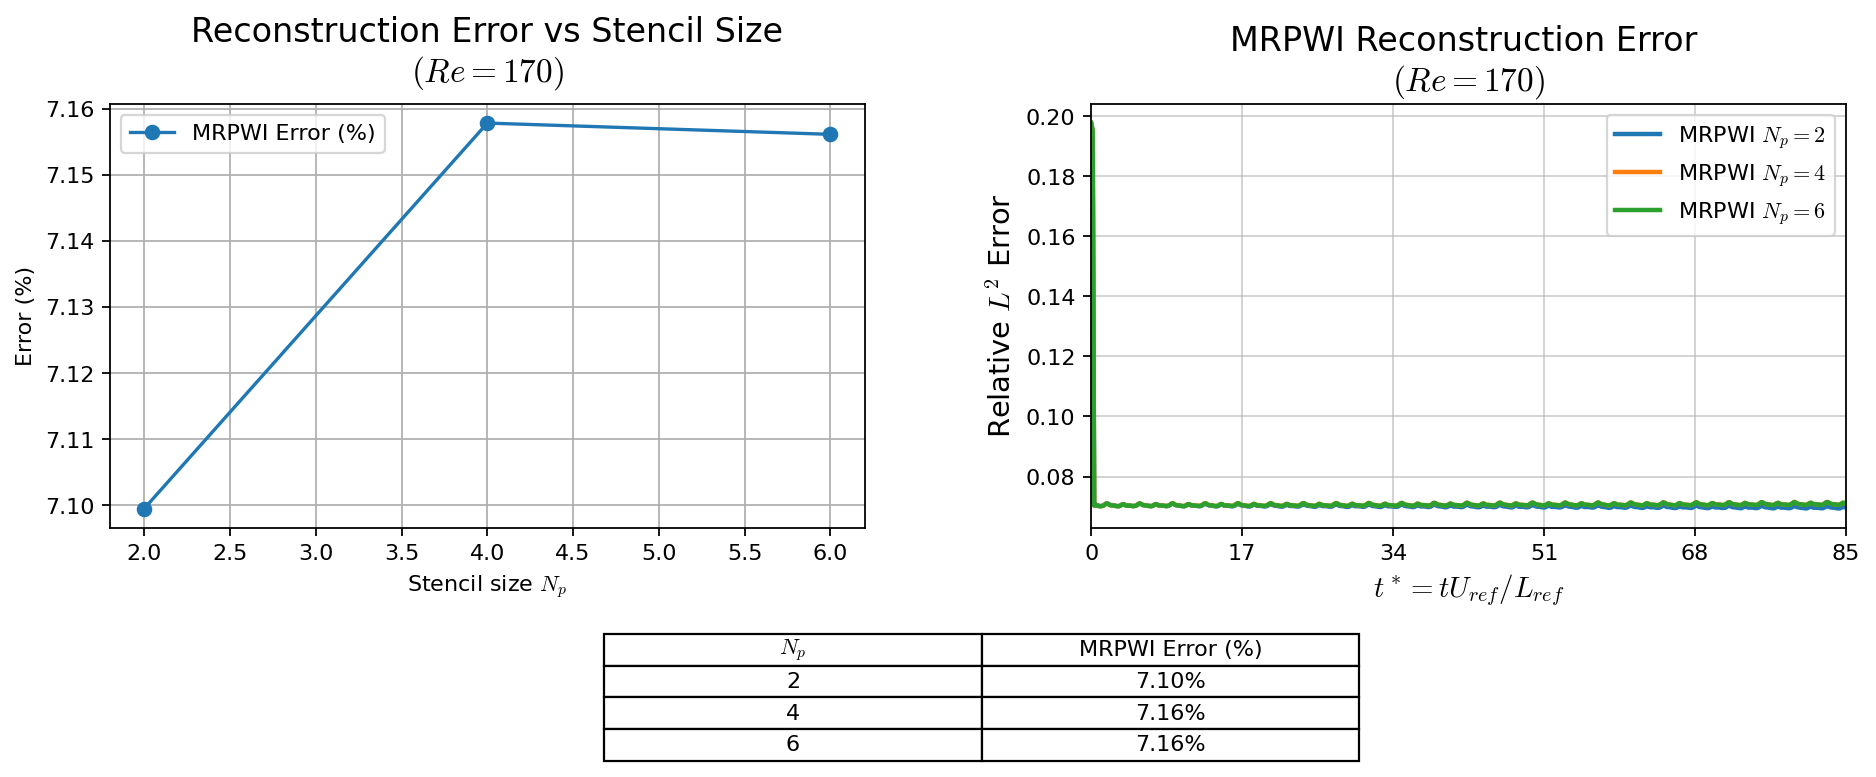

In [26]:
errors_aligned = {}

for Np in stencil_sets.keys():

    X_true = np.vstack([X_true_aligned, Cl_true_shifted.reshape(1, -1)])
    X_pred_aligned = recon_results_aligned[Np]

    err_aligned = np.linalg.norm(X_pred_aligned - X_true) / np.linalg.norm(X_true)
    errors_aligned[Np] = 100 * err_aligned


Np_values = sorted(stencil_sets.keys())
err_aligned_list = [errors_aligned[Np] for Np in Np_values]


t_vec = np.array(sampled_times_test_future, float)
U_ref = U_ref_test
time_nd = (t_vec - t_vec[0]) * U_ref / L_ref

X_true_full = np.vstack([X_true_aligned, Cl_true_shifted.reshape(1, -1)])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax1 = axes[0]
ax1.plot(Np_values, err_aligned_list, 'o-', label="MRPWI Error (%)")
ax1.set_xlabel(r"Stencil size $N_p$")
ax1.set_ylabel("Error (%)")
ax1.set_title(f"Reconstruction Error vs Stencil Size\n$(Re={Re_test})$", pad=10, fontsize=15)
ax1.legend()
ax1.grid(True)


ax2 = axes[1]

for Np in Np_values:
    X_recon_aligned = recon_results_aligned[Np].real
    abs_err = np.linalg.norm(X_true_full - X_recon_aligned, axis=0)
    rel_err = abs_err / np.linalg.norm(X_true_full, axis=0)
    ax2.plot(time_nd, rel_err, lw=2, label=f"MRPWI $N_p={Np}$")

ax2.set_xlabel(r"$t^* = t U_{ref}/L_{ref}$", fontsize=13)
ax2.set_ylabel("Relative $L^2$ Error", fontsize=13)
ax2.set_title(f"MRPWI Reconstruction Error \n$(Re={Re_test})$", fontsize=15)
ax2.grid(True, alpha=0.6)
ax2.legend()
ax2.set_xlim(0, time_nd[-1])
ax2.set_xticks(np.linspace(0, time_nd[-1], 6))


table_data = []
for Np, aligned in zip(Np_values, err_aligned_list):

    def fmt(val):
        if abs(val) >= 1e3 or (0 < abs(val) < 1e-2):
            return f"{val:.2e}%"
        else:
            return f"{val:.2f}%"

    table_data.append([Np, fmt(aligned)])


table = plt.table(
    cellText=table_data,
    colLabels=["$N_p$", "MRPWI Error (%)"],
    loc="bottom",
    cellLoc="center",
    bbox=[-0.645, -0.55, 1.0, 0.3]
)

table.auto_set_font_size(True)
table.set_fontsize(10)
table.scale(1, 1.2)

plt.subplots_adjust(bottom=0.35, wspace=0.3)
plt.show()


In [27]:
# Load test parameter snapshots
loader_test = FOAMDataloader(path_test)
vertices_test = loader_test.vertices[:, :2]

mask_indices_test = np.where(mask_test.numpy())[0]

training_window = (10.0, 15.0)
times_test = loader_test.write_times   

# Convert to float for filtering
times_test_float = np.array([float(t) for t in times_test], dtype=float)

# Select indices inside the training window
idx_window = np.where(
    (times_test_float >= training_window[0]) &
    (times_test_float <= training_window[1])
)[0]

sampling_step = 1
idx_sampled = idx_window[::sampling_step]

train_times_test = [times_test[i] for i in idx_sampled]

# Load masked snapshots
snapshot_test_train, _ = loader.load_masked_matrix(
    loader_test,
    mask_indices_test,
    train_times_test
)

print("Loaded test TRAINING snapshots:", snapshot_test_train.shape)


# Load Cl(t) for the TEST TRAINING WINDOW

# Path to forceCoeffs file
force_file = os.path.join(path_test, "postProcessing", "forces", "0", "coefficient.dat")

# Load forceCoeffs.dat
data = np.loadtxt(force_file, comments="#", delimiter=None)

# Columns: [time, Cd, Cl, Cm, ...]
cl_times_all = data[:, 0]
cl_all       = data[:, 2]

# Filter into training window
idx_cl = np.where(
    (cl_times_all >= training_window[0]) &
    (cl_times_all <= training_window[1])
)[0]

Cl_true  = cl_all[idx_cl][::sampling_step]
Cl_times = cl_times_all[idx_cl][::sampling_step]

# Phase-align Cl
shift_idx = np.argmax(Cl_true)
Cl_true_shifted = np.roll(Cl_true, -shift_idx)

print("Loaded and aligned test Cl(t):", Cl_true_shifted.shape)


[2026-04-06 22:37:35] INFO     Loading precomputed cell centers and volumes from processor0/constant
[2026-04-06 22:37:35] INFO     Loading precomputed cell centers and volumes from processor1/constant


Loaded test TRAINING snapshots: (11492, 501)
Loaded and aligned test Cl(t): (501,)


In [28]:
# Build augmented test training state
X_test_train_aug = np.vstack([
    snapshot_test_train, 
    Cl_true_shifted.reshape(1, -1)
])

# Convert to torch
X_test_train_pt = pt.tensor(X_test_train_aug, dtype=pt.float64)

# Compute dt
times_test_float_sampled = np.array([float(t) for t in train_times_test])
dt_test = times_test_float_sampled[1] - times_test_float_sampled[0]

rank_test = 30

# Fit DMD model for the test parameter μ*
dmd_test = DMD(
    X_test_train_pt,
    dt = dt_test,
    rank = rank_test,
    tlsq = False,
    unitary = False,
    optimal = False,
    forward_backward = False
)

print("DMD fitted for test parameter.")
print("Test DMD state dimension:", X_test_train_pt.shape)


[2026-04-06 22:37:37] INFO     Computing economy SVD via Gram matrix and eigendecomposition
[2026-04-06 22:37:37] INFO     Truncating SVD at index 30/500


DMD fitted for test parameter.
Test DMD state dimension: torch.Size([11493, 501])


In [29]:

# Mode ranking + conjugate pairing for the TEST DMD model

# Raw DMD modes for test case
Phi_test = dmd_test.modes.detach().cpu().numpy()

# Continuous-time eigenvalues λ_j for test case
s_test = dmd_test.eigvals_cont.detach().cpu().numpy()

# Number of dominant modes to keep
top_k_test = dmd_test.svd.rank

# Rank modes by importance (same method as training)
top_idx_test = dmd_test.top_modes(n=len(s_test), integral=True).detach().cpu().numpy()

# Keep top‑k modes
Phi_sorted_test = Phi_test[:, top_idx_test[:top_k_test]]
s_sorted_test   = s_test[top_idx_test[:top_k_test]]

# Conjugate‑pair ordering (same logic as training)

ordered_modes_test = []
ordered_eigs_test  = []
used = np.zeros(len(s_sorted_test), dtype=bool)

for j in range(len(s_sorted_test)):

    if used[j]:
        continue

    eig = s_sorted_test[j]
    conj_found = False

    # Find conjugate partner
    conj_idx = np.where(np.isclose(s_sorted_test, np.conj(eig)))[0]

    if len(conj_idx) > 0 and conj_idx[0] != j:
        k = conj_idx[0]
        used[j] = True
        used[k] = True
        conj_found = True

        # Order pair: positive imaginary part first
        if np.imag(eig) >= 0:
            ordered_eigs_test.extend([eig, s_sorted_test[k]])
            ordered_modes_test.extend([Phi_sorted_test[:, j], Phi_sorted_test[:, k]])
        else:
            ordered_eigs_test.extend([s_sorted_test[k], eig])
            ordered_modes_test.extend([Phi_sorted_test[:, k], Phi_sorted_test[:, j]])

    # Real eigenvalue (no conjugate partner)
    if not conj_found:
        used[j] = True
        ordered_eigs_test.append(eig)
        ordered_modes_test.append(Phi_sorted_test[:, j])

# Convert to arrays
ordered_modes_test = np.column_stack(ordered_modes_test)
ordered_eigs_test  = np.array(ordered_eigs_test)

print("Test DMD modes shape (before alignment):", ordered_modes_test.shape)
print("Test DMD eigenvalues:", ordered_eigs_test)

# PHASE ALIGNMENT OF TEST MODES TO THE SAME REFERENCE

# Reference modes used during training alignment
Phi_ref = selected_modes_dict[Re_ref]   # shape (n_space, r)

Phi_test_aligned = []

for k in range(ordered_modes_test.shape[1]):
    phi_ref = Phi_ref[:, k]                 # reference mode k
    phi_cur = ordered_modes_test[:, k]      # test mode k (unaligned)

    # Compute phase difference
    angle = np.angle(np.vdot(phi_ref, phi_cur))

    # Rotate test mode to match reference phase
    Phi_test_aligned.append(phi_cur * np.exp(-1j * angle))

Phi_test_aligned = np.column_stack(Phi_test_aligned)

print("Aligned TEST modes shape:", Phi_test_aligned.shape)


Test DMD modes shape (before alignment): (11493, 30)
Test DMD eigenvalues: [ 7.23731963e-08  +0.j         -5.71911468e-06 +28.96909048j
 -5.71911468e-06 -28.96909048j -1.54835151e-05 +57.93814635j
 -1.54835151e-05 -57.93814635j -1.58737548e-05 +86.90726569j
 -1.58737548e-05 -86.90726569j -2.87336754e-05+115.87636473j
 -2.87336754e-05-115.87636473j  3.55180675e-05+144.84551068j
  3.55180675e-05-144.84551068j -2.31384055e-05+173.81454296j
 -2.31384055e-05-173.81454296j  8.90575863e-05+202.78378749j
  8.90575863e-05-202.78378749j  7.43573074e-05+231.7527821j
  7.43573074e-05-231.7527821j  -6.04091724e-04+260.72202363j
 -6.04091724e-04-260.72202363j -8.43884563e-03+289.69395314j
 -8.43884563e-03-289.69395314j -2.59327110e-02+309.64315818j
 -2.59327110e-02-309.64315818j -3.39374396e-01+280.28000778j
 -3.39374396e-01-280.28000778j -1.44134506e+00+250.96791012j
 -1.44134506e+00-250.96791012j -1.80512117e+01  +0.j
 -5.42140355e+00  +0.j         -1.57713230e+02+314.15926536j]
Aligned TEST modes

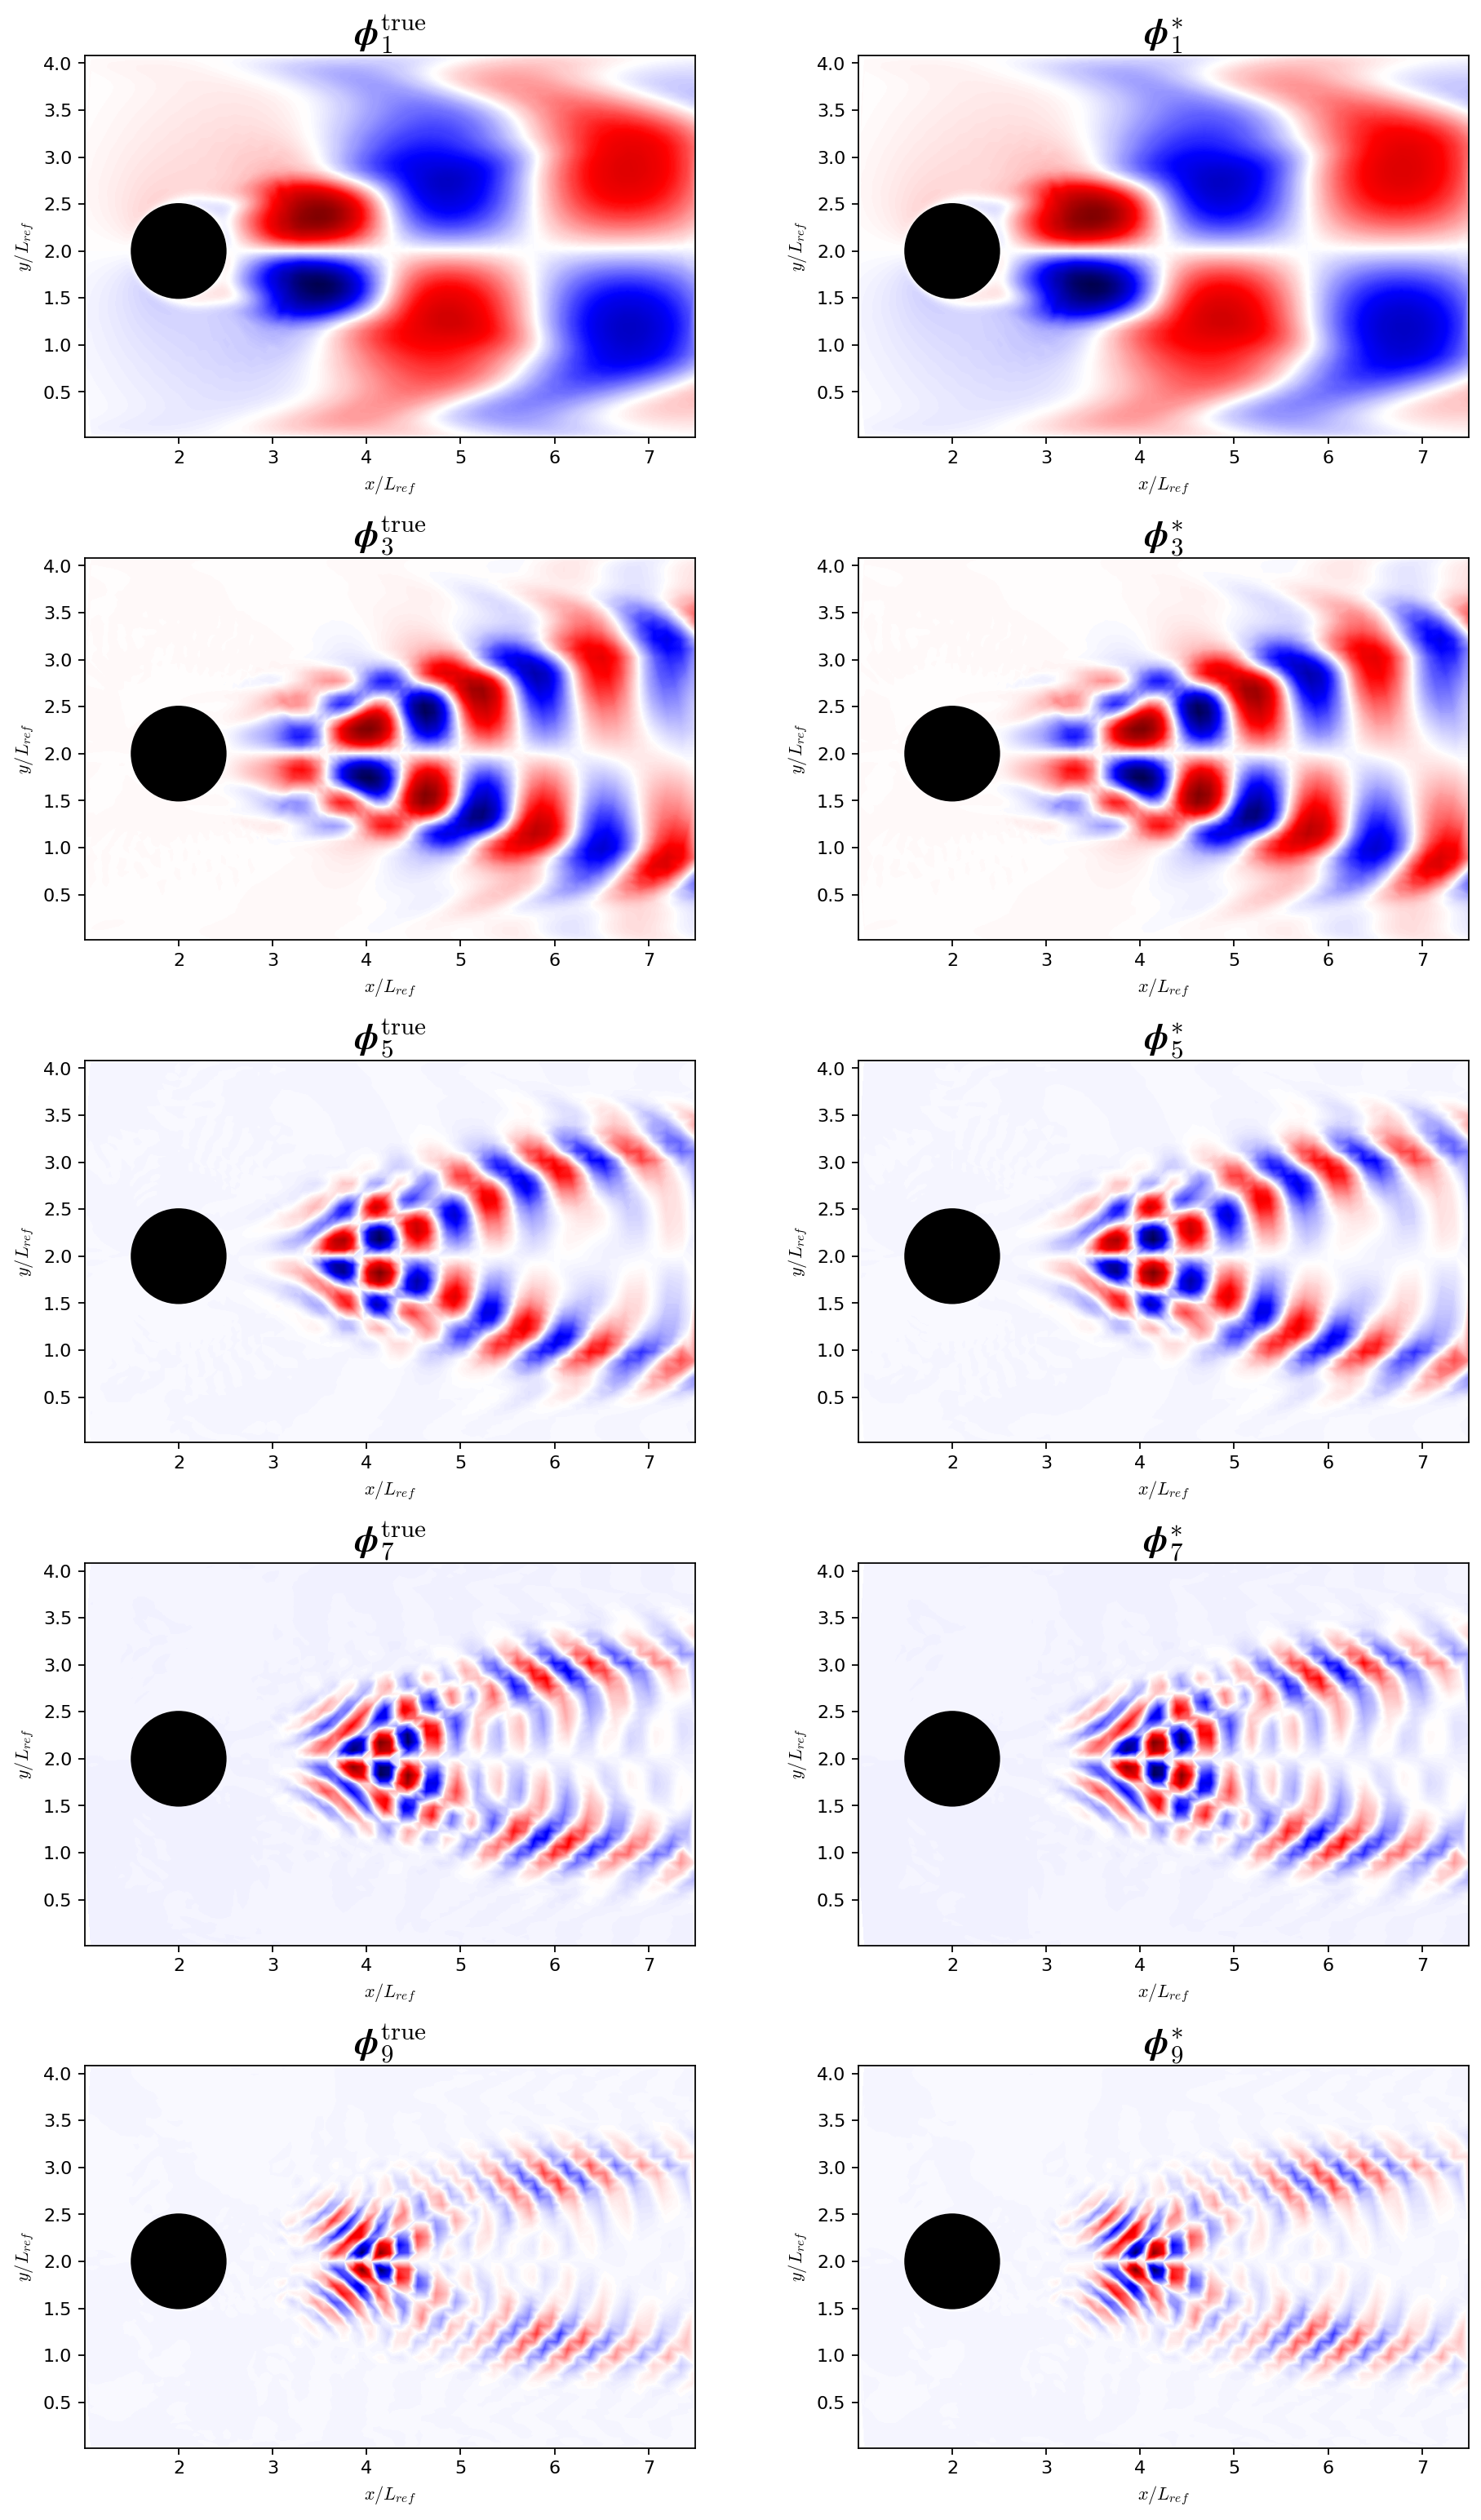

In [30]:
Np = 2
modes_to_show = 5

coords = train.coords
coords_nd = coords / L_ref
num_points = train.num_points

Phi_interp = interp_modes_aligned[Np]     # (2*num_points+1, r)
Phi_true   = Phi_test_aligned             # (2*num_points+1, r)

# Remove Cl row
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

# remove mean mode
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]

# remove conjugate pairs
s_interp_full = interp_eigs_aligned[Np][1:]
freqs_interp_full = s_interp_full.imag
unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)
Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]

# select odd modes 1,3,5,...
odd_idx = list(range(0, Phi_interp.shape[1], 2))
Phi_interp = Phi_interp[:, odd_idx]
Phi_true   = Phi_true[:, odd_idx]

r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

# One big figure: rows = modes, cols = 2
fig, axarr = plt.subplots(
    modes_to_show, 2,
    figsize=(12, 4 * modes_to_show)
)

if modes_to_show == 1:
    axarr = np.array([axarr])

for k in range(modes_to_show):

    # Extract scalar field for plotting (quietly use Re(u))
    phi_interp = Phi_interp[:num_points, k].real
    phi_true   = Phi_true[:num_points, k].real

    # Titles
    mode_number = 2*k + 1
    title_interp = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{*}}$"
    title_true   = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mathrm{{true}}}}$"

    # True 
    axarr[k, 0].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phi_true,
        levels=300, cmap="seismic"
    )
    axarr[k, 0].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 0].set_title(title_true, fontsize=20)
    axarr[k, 0].set_aspect("equal")

    # Interpolated 
    axarr[k, 1].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phi_interp,
        levels=300, cmap="seismic"
    )
    axarr[k, 1].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 1].set_title(title_interp, fontsize=20)
    axarr[k, 1].set_aspect("equal")


    # Axis labels 
    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/L_{ref}$")
        axarr[k, j].set_ylabel(r"$y/L_{ref}$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


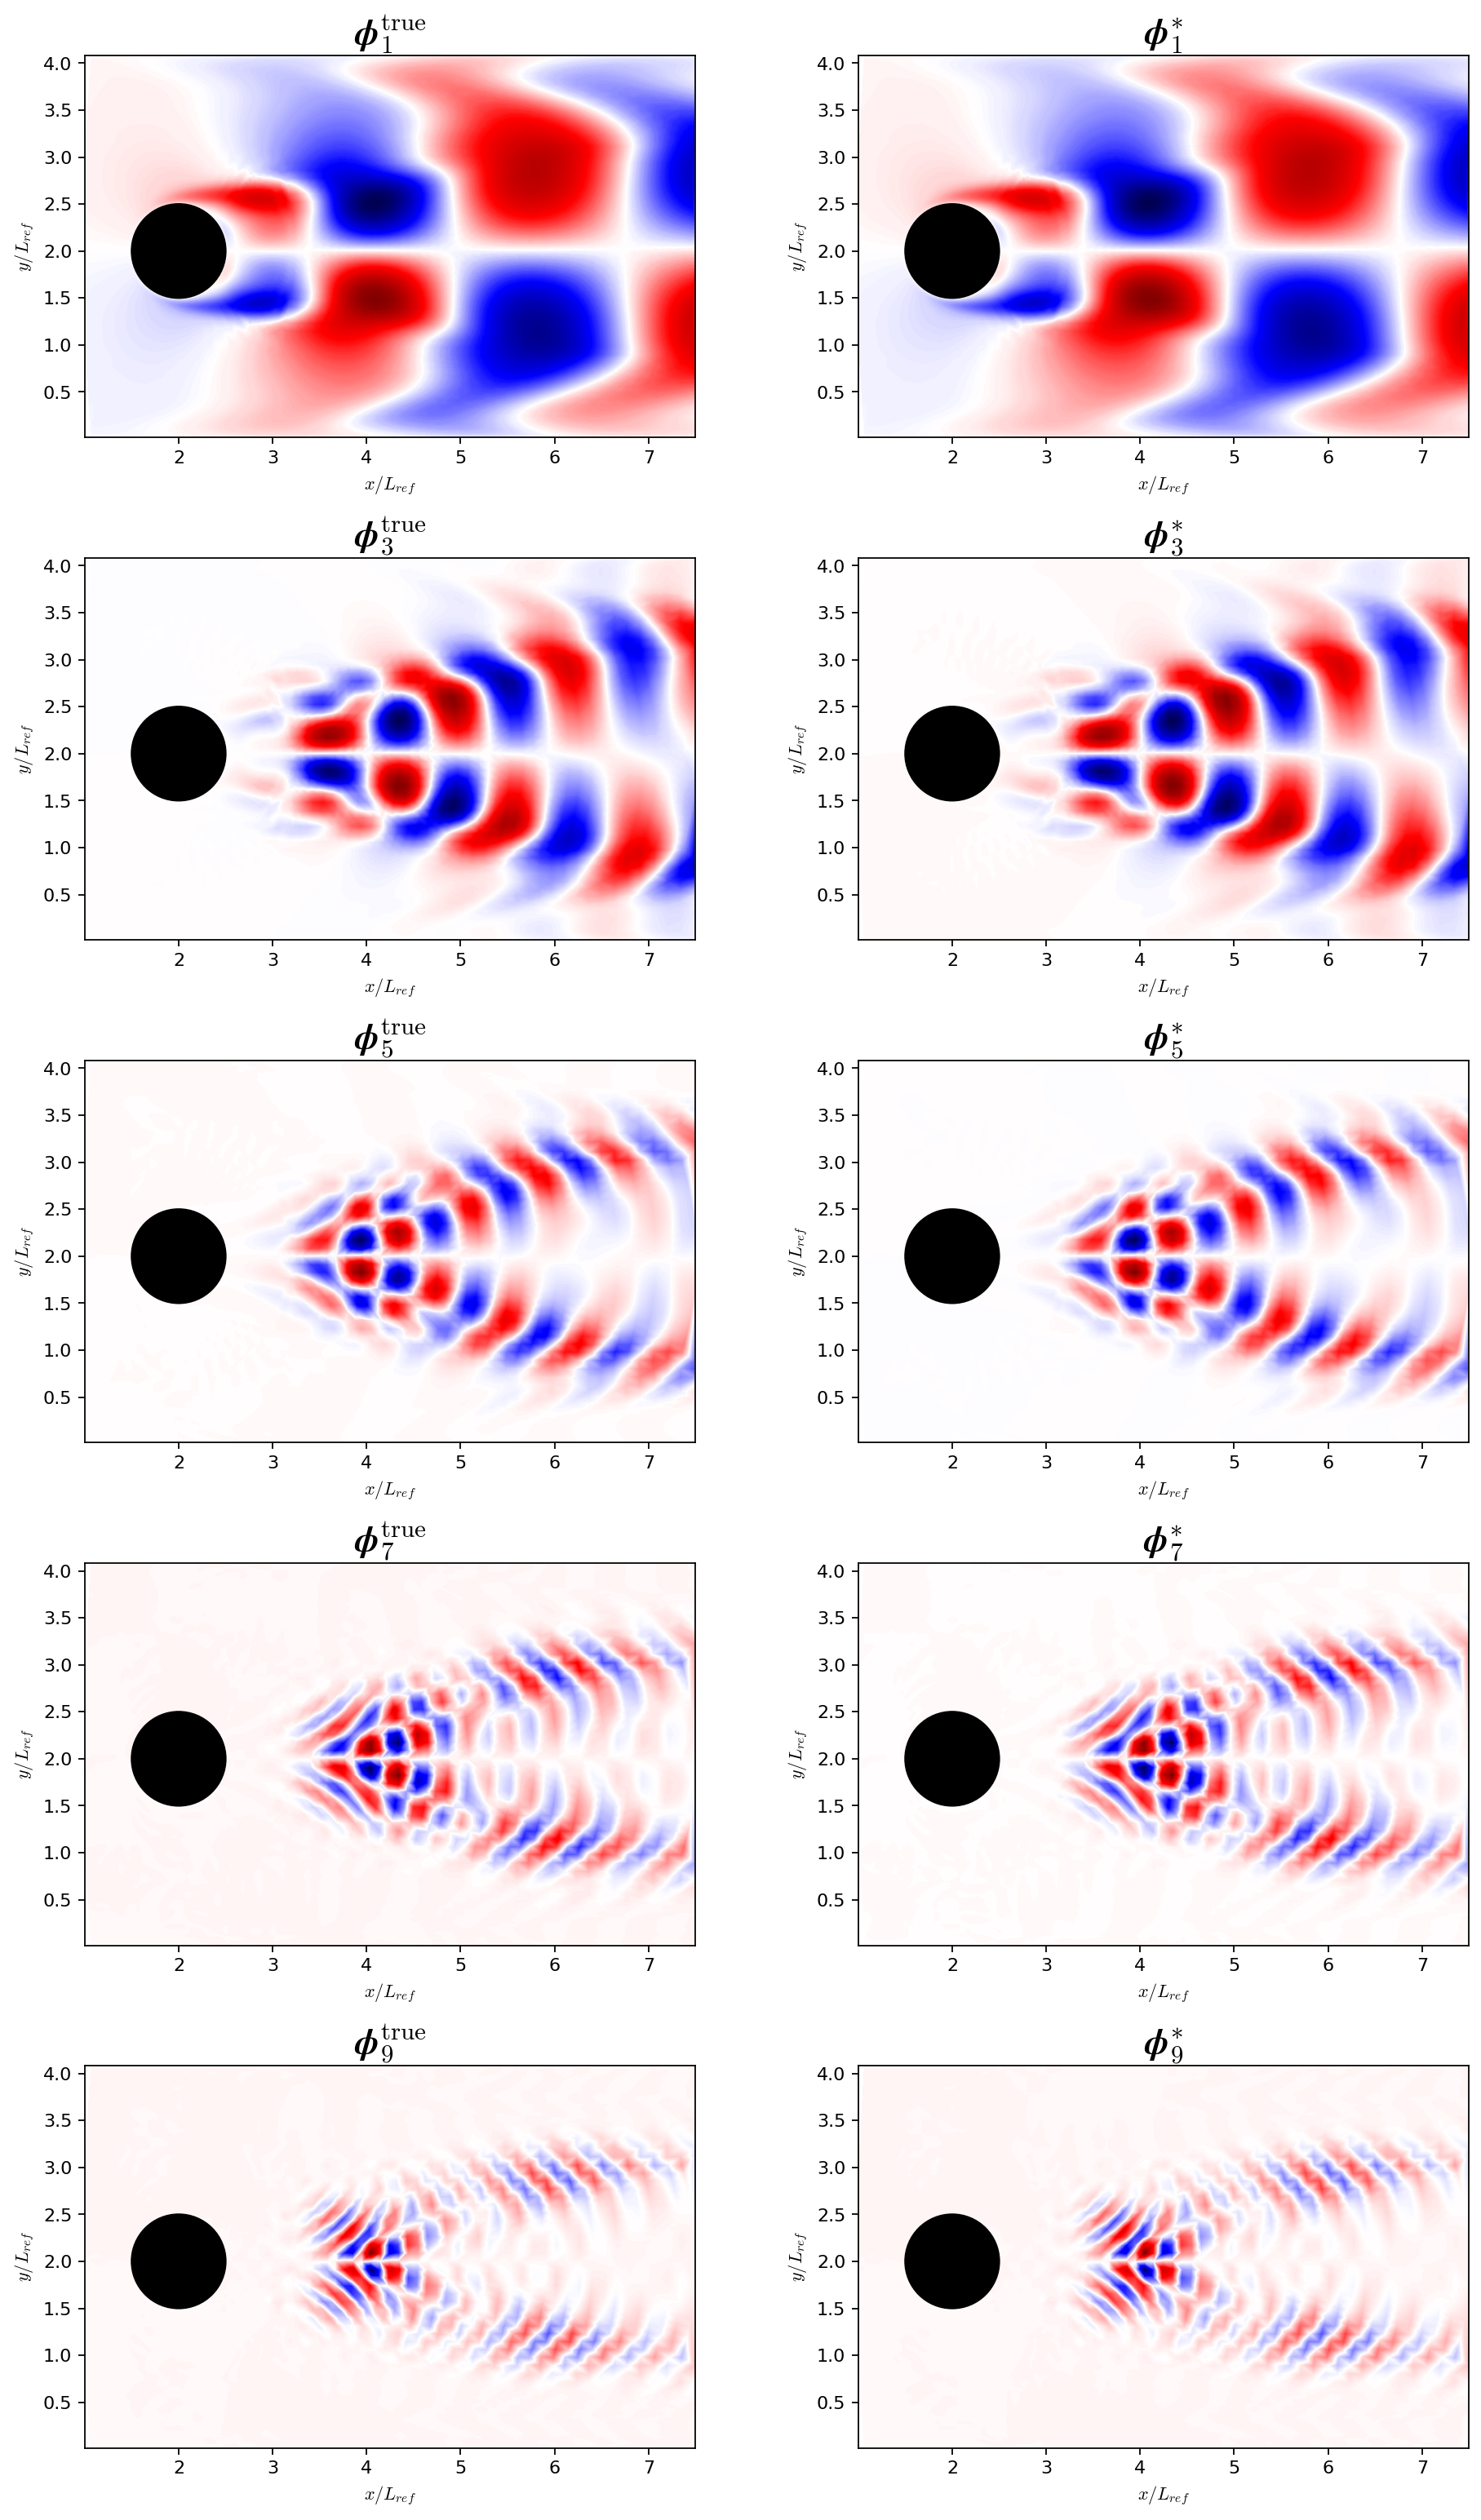

In [31]:
Np = 2
modes_to_show = 5

coords = train.coords
coords_nd = coords / L_ref
num_points = train.num_points

Phi_interp = interp_modes_aligned[Np]     # (2*num_points+1, r)
Phi_true   = Phi_test_aligned             # (2*num_points+1, r)

# Remove Cl row
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

# remove mean mode
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]

# remove conjugate pairs
s_interp_full = interp_eigs_aligned[Np][1:]
freqs_interp_full = s_interp_full.imag
unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)
Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]

# select odd modes 1,3,5,...
odd_idx = list(range(0, Phi_interp.shape[1], 2))
Phi_interp = Phi_interp[:, odd_idx]
Phi_true   = Phi_true[:, odd_idx]

r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

# One big figure: rows = modes, cols = 2
fig, axarr = plt.subplots(
    modes_to_show, 2,
    figsize=(12, 4 * modes_to_show)
)

if modes_to_show == 1:
    axarr = np.array([axarr])

for k in range(modes_to_show):

    # Extract scalar field for plotting (quietly use Re(u))
    phi_interp = Phi_interp[:num_points, k].imag
    phi_true   = Phi_true[:num_points, k].imag

    # Titles
    mode_number = 2*k + 1
    title_interp = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{*}}$"
    title_true   = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mathrm{{true}}}}$"

    # True 
    axarr[k, 0].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phi_true,
        levels=300, cmap="seismic"
    )
    axarr[k, 0].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 0].set_title(title_true, fontsize=20)
    axarr[k, 0].set_aspect("equal")

    # Interpolated 
    axarr[k, 1].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phi_interp,
        levels=300, cmap="seismic"
    )
    axarr[k, 1].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 1].set_title(title_interp, fontsize=20)
    axarr[k, 1].set_aspect("equal")


    # Axis labels 
    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/L_{ref}$")
        axarr[k, j].set_ylabel(r"$y/L_{ref}$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


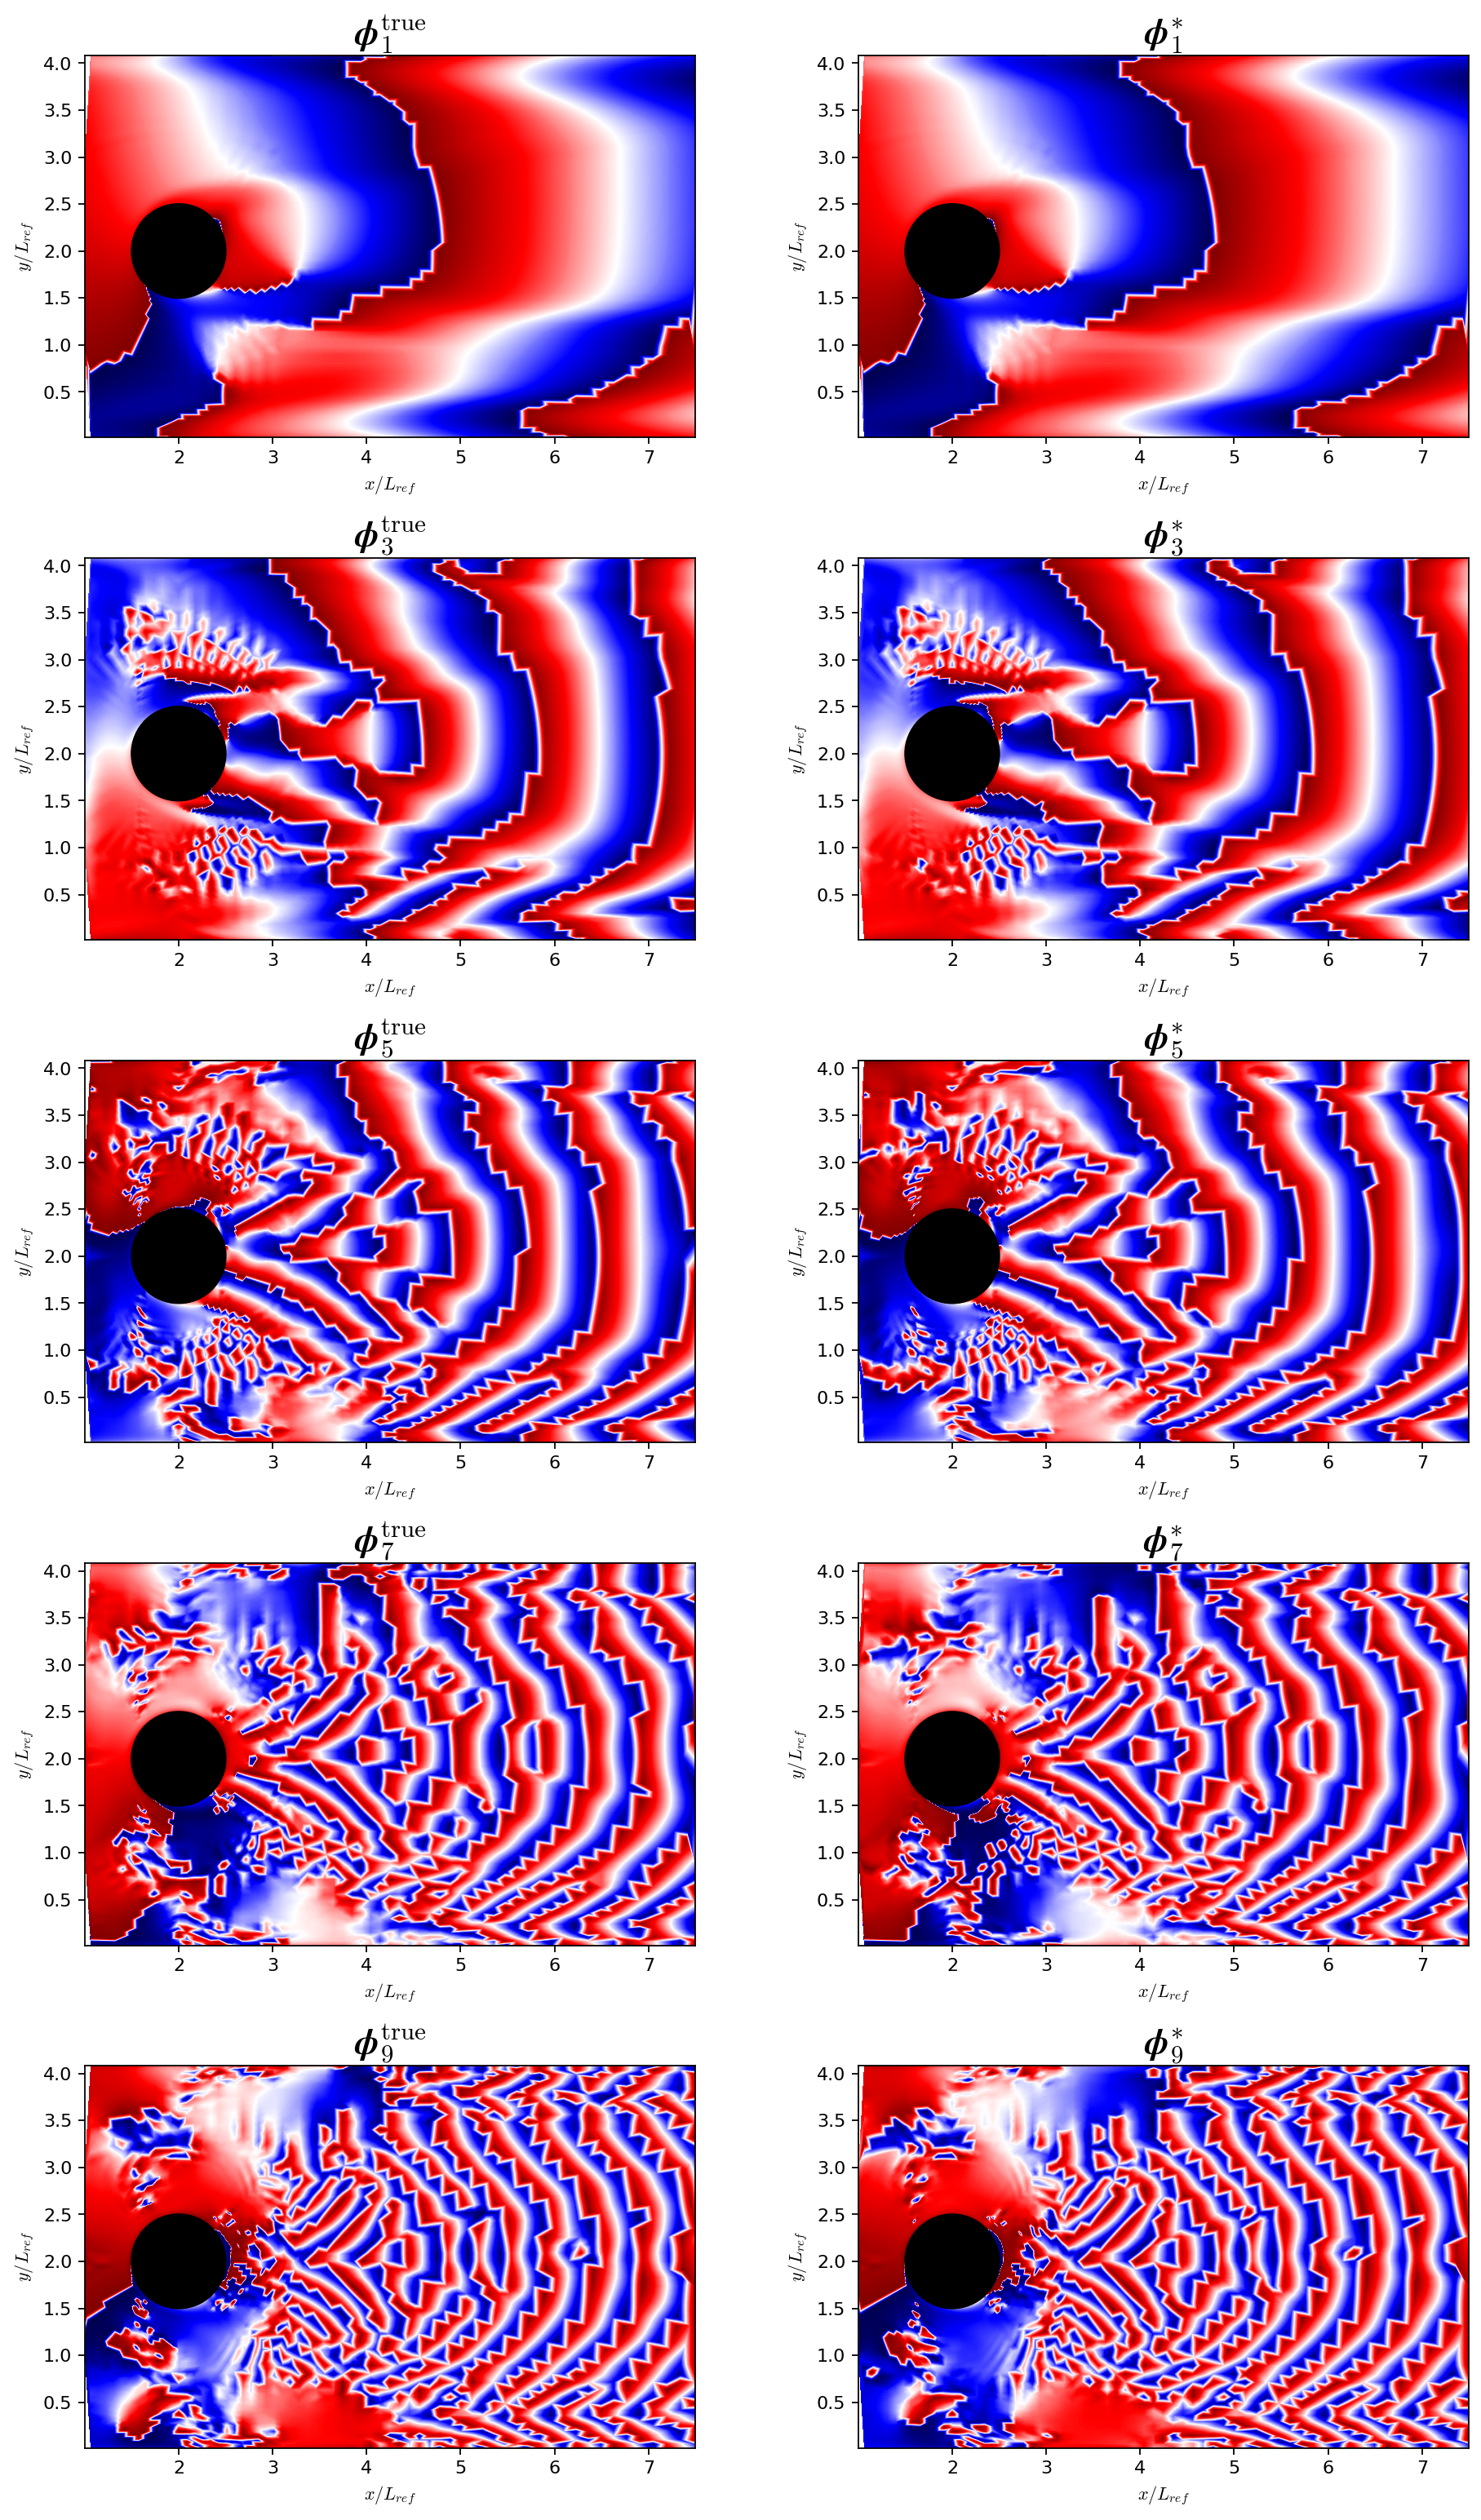

In [32]:
Np = 2
modes_to_show = 5

coords = train.coords
coords_nd = coords / L_ref
num_points = train.num_points

Phi_interp = interp_modes_aligned[Np]
Phi_true   = Phi_test_aligned

# Remove the Cl row
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

# remove mean mode
Phi_interp = Phi_interp[:, 1:]
Phi_true   = Phi_true[:, 1:]

# remove conjugate pairs
s_interp_full = interp_eigs_aligned[Np][1:]
freqs_interp_full = s_interp_full.imag
unique_idx = []
used = set()
for i, w in enumerate(freqs_interp_full):
    key = round(abs(float(w)), 8)
    if key not in used:
        used.add(key)
        unique_idx.append(i)
Phi_interp = Phi_interp[:, unique_idx]
Phi_true   = Phi_true[:, unique_idx]

# select odd modes 1,3,5,...
odd_idx = list(range(0, Phi_interp.shape[1], 2))
Phi_interp = Phi_interp[:, odd_idx]
Phi_true   = Phi_true[:, odd_idx]

r = Phi_interp.shape[1]
modes_to_show = min(modes_to_show, r)

fig, axarr = plt.subplots(
    modes_to_show, 2,
    figsize=(12, 4 * modes_to_show)
)

if modes_to_show == 1:
    axarr = np.array([axarr])

cmap_phase = "seismic"

for k in range(modes_to_show):

    # Extract complex mode
    phi_interp = Phi_interp[:, k]
    phi_true   = Phi_true[:, k]

    # Split into u and v
    u_interp = phi_interp[:num_points]
    v_interp = phi_interp[num_points:]
    u_true   = phi_true[:num_points]
    v_true   = phi_true[num_points:]

    # Compute phase of vector field
    phase_interp = np.angle(u_interp + 1j * v_interp)
    phase_true   = np.angle(u_true   + 1j * v_true)

    # Titles
    mode_number = 2*k + 1
    title_interp = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{*}}$"
    title_true   = rf"$\boldsymbol{{\phi}}_{{{mode_number}}}^{{\mathrm{{true}}}}$"

    # True
    axarr[k, 0].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phase_true,
        levels=300, cmap=cmap_phase
    )
    axarr[k, 0].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 0].set_title(title_true, fontsize=20)
    axarr[k, 0].set_aspect("equal")

    # Interpolated
    axarr[k, 1].tricontourf(
        coords_nd[:, 0], coords_nd[:, 1], phase_interp,
        levels=300, cmap=cmap_phase
    )
    axarr[k, 1].add_patch(Circle((0.2/L_ref, 0.2/L_ref), 0.05/L_ref, color='black'))
    axarr[k, 1].set_title(title_interp, fontsize=20)
    axarr[k, 1].set_aspect("equal")

    for j in range(2):
        axarr[k, j].set_xlabel(r"$x/L_{ref}$")
        axarr[k, j].set_ylabel(r"$y/L_{ref}$")
        axarr[k, j].tick_params(labelbottom=True, labelleft=True)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [33]:
Np = 2          # stencil size
modes = 10      # number of modes to evaluate
component = "full"        # "u", "v", or "full"

Phi_interp = interp_modes_aligned[Np]
Phi_true   = Phi_test_aligned

# FIX: remove the extra row from BOTH
Phi_interp = Phi_interp[:-1, :]
Phi_true   = Phi_true[:-1, :]

s_interp = interp_eigs_aligned[Np]
s_true   = ordered_eigs_test

num_points = train.num_points
r = Phi_interp.shape[1]
modes = min(modes, r)

# Eigenvalue interpolation error
eig_abs_error = np.abs(s_interp[:modes] - s_true[:modes])
eig_rel_error = eig_abs_error / np.maximum(np.abs(s_true[:modes]), 1e-12)

print("\n Eigenvalue Interpolation Error")
for k in range(modes):
    print(f"Mode {k+1}: |Δλ| = {eig_abs_error[k]:.3e},  rel = {eig_rel_error[k]:.3e}")

# Mode interpolation error

def extract_component(phi, comp):
    if comp == "u":
        return phi[:num_points]
    elif comp == "v":
        return phi[num_points:]
    elif comp == "full":
        return phi
    else:
        raise ValueError("component must be 'u', 'v', or 'full'")

print("\n Mode Interpolation Error ")
mode_errors = []

for k in range(modes):

    phi_i = Phi_interp[:, k]
    phi_t = Phi_true[:, k]

    comp_i = extract_component(phi_i, component)
    comp_t = extract_component(phi_t, component)

    abs_err = np.linalg.norm(comp_i - comp_t)
    rel_err = abs_err / (np.linalg.norm(comp_t) + 1e-12)

    mode_errors.append((abs_err, rel_err))

    print(f"Mode {k+1}:  L2 = {abs_err:.3e},  rel = {rel_err:.3e}")



 Eigenvalue Interpolation Error
Mode 1: |Δλ| = 2.455e-08,  rel = 3.393e-01
Mode 2: |Δλ| = 1.404e-03,  rel = 4.848e-05
Mode 3: |Δλ| = 1.404e-03,  rel = 4.848e-05
Mode 4: |Δλ| = 2.836e-03,  rel = 4.895e-05
Mode 5: |Δλ| = 2.836e-03,  rel = 4.895e-05
Mode 6: |Δλ| = 4.193e-03,  rel = 4.825e-05
Mode 7: |Δλ| = 4.193e-03,  rel = 4.825e-05
Mode 8: |Δλ| = 5.601e-03,  rel = 4.833e-05
Mode 9: |Δλ| = 5.601e-03,  rel = 4.833e-05
Mode 10: |Δλ| = 6.944e-03,  rel = 4.794e-05

 Mode Interpolation Error 
Mode 1:  L2 = 5.013e-04,  rel = 5.014e-04
Mode 2:  L2 = 2.184e-03,  rel = 2.184e-03
Mode 3:  L2 = 2.184e-03,  rel = 2.184e-03
Mode 4:  L2 = 7.295e-03,  rel = 7.295e-03
Mode 5:  L2 = 7.295e-03,  rel = 7.295e-03
Mode 6:  L2 = 8.421e-03,  rel = 8.421e-03
Mode 7:  L2 = 8.421e-03,  rel = 8.421e-03
Mode 8:  L2 = 1.365e-02,  rel = 1.365e-02
Mode 9:  L2 = 1.365e-02,  rel = 1.365e-02
Mode 10:  L2 = 2.268e-02,  rel = 2.268e-02


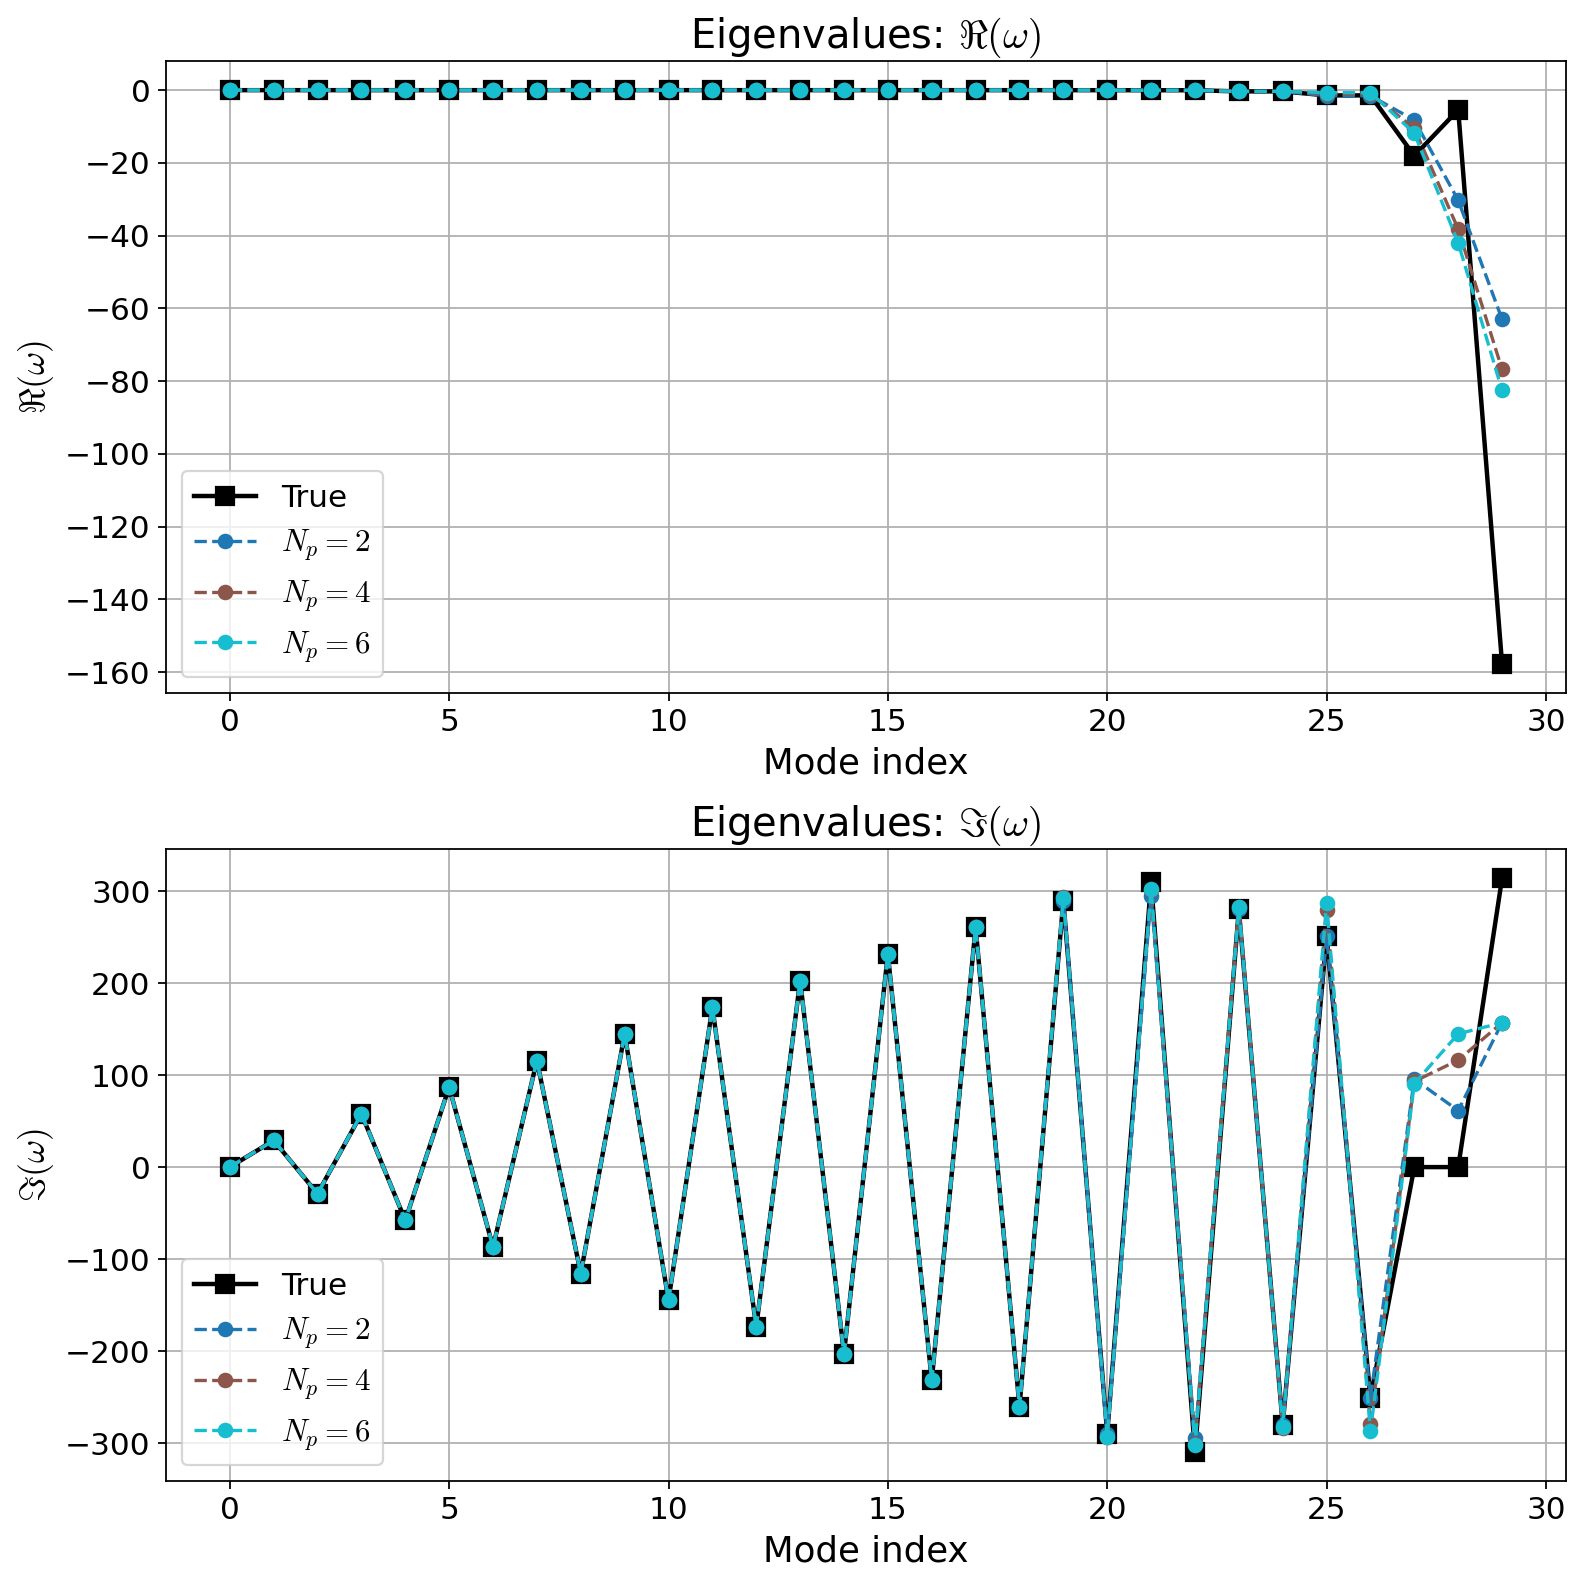

In [34]:
r_plot = r_recon   # or set manually

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

# TOP: REAL PART
ax[0].plot(
    ordered_eigs_test[:r_plot].real,
    marker='s', linestyle='-', color='black',
    linewidth=2, markersize=8,
    label="True"
)

for (Np, c) in zip(stencil_sets.keys(), plt.cm.tab10(np.linspace(0,1,len(stencil_sets)))):
    s_interp = interp_eigs_aligned[Np][:r_plot]
    ax[0].plot(
        s_interp.real,
        marker='o', linestyle='--', color=c,
        linewidth=1.5, markersize=6,
        label=rf"$N_p={Np}$"
    )

ax[0].set_title(r"Eigenvalues: $\Re(\omega)$", fontsize=18)
ax[0].set_xlabel("Mode index", fontsize=16)
ax[0].set_ylabel(r"$\Re(\omega)$", fontsize=16)
ax[0].tick_params(labelsize=14)
ax[0].grid(True)
ax[0].legend(fontsize=14)

# BOTTOM: IMAG PART
ax[1].plot(
    ordered_eigs_test[:r_plot].imag,
    marker='s', linestyle='-', color='black',
    linewidth=2, markersize=8,
    label="True"
)

for (Np, c) in zip(stencil_sets.keys(), plt.cm.tab10(np.linspace(0,1,len(stencil_sets)))):
    s_interp = interp_eigs_aligned[Np][:r_plot]
    ax[1].plot(
        s_interp.imag,
        marker='o', linestyle='--', color=c,
        linewidth=1.5, markersize=6,
        label=rf"$N_p={Np}$"
    )

ax[1].set_title(r"Eigenvalues: $\Im(\omega)$", fontsize=18)
ax[1].set_xlabel("Mode index", fontsize=16)
ax[1].set_ylabel(r"$\Im(\omega)$", fontsize=16)
ax[1].tick_params(labelsize=14)
ax[1].grid(True)
ax[1].legend(loc="lower left", fontsize=14)

plt.tight_layout()
plt.show()



=== Eigenvalue Error for Selected r Values ===

--- Stencil size Np = 2 ---
  r= 5: error = 4.8854e-05
  r=10: error = 4.8263e-05
  r=15: error = 4.8130e-05
  r=20: error = 4.8376e-05
  r=25: error = 2.0725e-02
  r=30: error = 1.9575e-01
--- Stencil size Np = 4 ---
  r= 5: error = 2.3535e-05
  r=10: error = 2.4044e-05
  r=15: error = 2.4126e-05
  r=20: error = 4.6093e-03
  r=25: error = 1.3320e-02
  r=30: error = 2.1280e-01
--- Stencil size Np = 6 ---
  r= 5: error = 2.4318e-05
  r=10: error = 2.4759e-05
  r=15: error = 2.4797e-05
  r=20: error = 4.5800e-03
  r=25: error = 1.1440e-02
  r=30: error = 2.2616e-01


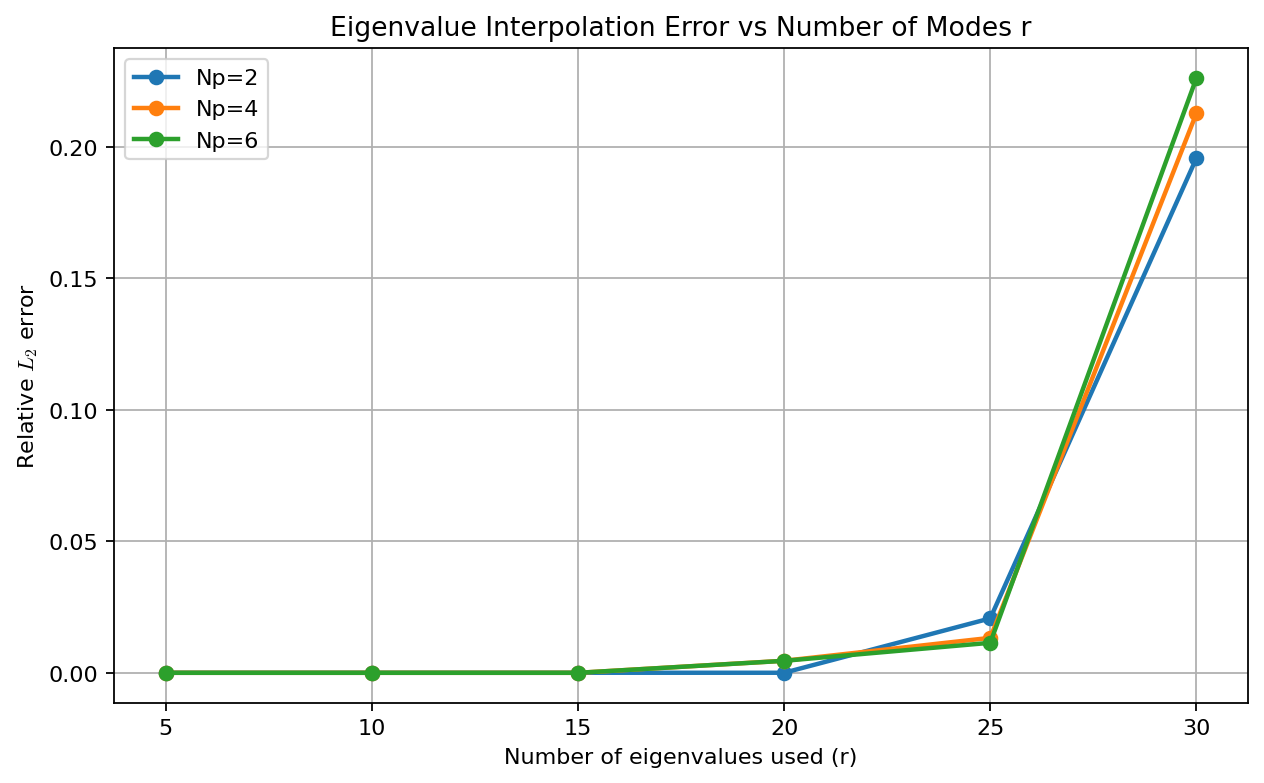

In [35]:
# Choose the number of eigenvalues you want to test
r_values = [5, 10, 15, 20, 25, 30]   

stencil_sizes = sorted(interp_eigs_aligned.keys())
errors_by_r = {Np: [] for Np in stencil_sizes}

print("\n=== Eigenvalue Error for Selected r Values ===\n")

for Np in stencil_sizes:
    s_pred = interp_eigs_aligned[Np]
    s_true = ordered_eigs_test

    print(f"--- Stencil size Np = {Np} ---")

    for r in r_values:
        err_r = np.linalg.norm(s_pred[:r] - s_true[:r]) / np.linalg.norm(s_true[:r])
        errors_by_r[Np].append(err_r)

        print(f"  r={r:2d}: error = {err_r:.4e}")

# Plot
plt.figure(figsize=(8,5))

for Np in stencil_sizes:
    plt.plot(r_values, errors_by_r[Np], "-o", linewidth=2, label=f"Np={Np}")

plt.xlabel("Number of eigenvalues used (r)")
plt.ylabel("Relative $L_2$ error")
plt.title("Eigenvalue Interpolation Error vs Number of Modes r")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



=== Modal Interpolation Error for Selected r Values ===

--- Stencil size Np = 2 ---
  r= 5: mean modal error = 2.4362e-02
  r=10: mean modal error = 2.8464e-01
  r=15: mean modal error = 2.8464e-01
  r=20: mean modal error = 2.8464e-01
  r=25: mean modal error = 2.8464e-01
  r=30: mean modal error = 2.8464e-01
--- Stencil size Np = 4 ---
  r= 5: mean modal error = 3.7441e-03
  r=10: mean modal error = 3.0466e-01
  r=15: mean modal error = 3.0466e-01
  r=20: mean modal error = 3.0466e-01
  r=25: mean modal error = 3.0466e-01
  r=30: mean modal error = 3.0466e-01
--- Stencil size Np = 6 ---
  r= 5: mean modal error = 2.9680e-03
  r=10: mean modal error = 3.4279e-01
  r=15: mean modal error = 3.4279e-01
  r=20: mean modal error = 3.4279e-01
  r=25: mean modal error = 3.4279e-01
  r=30: mean modal error = 3.4279e-01


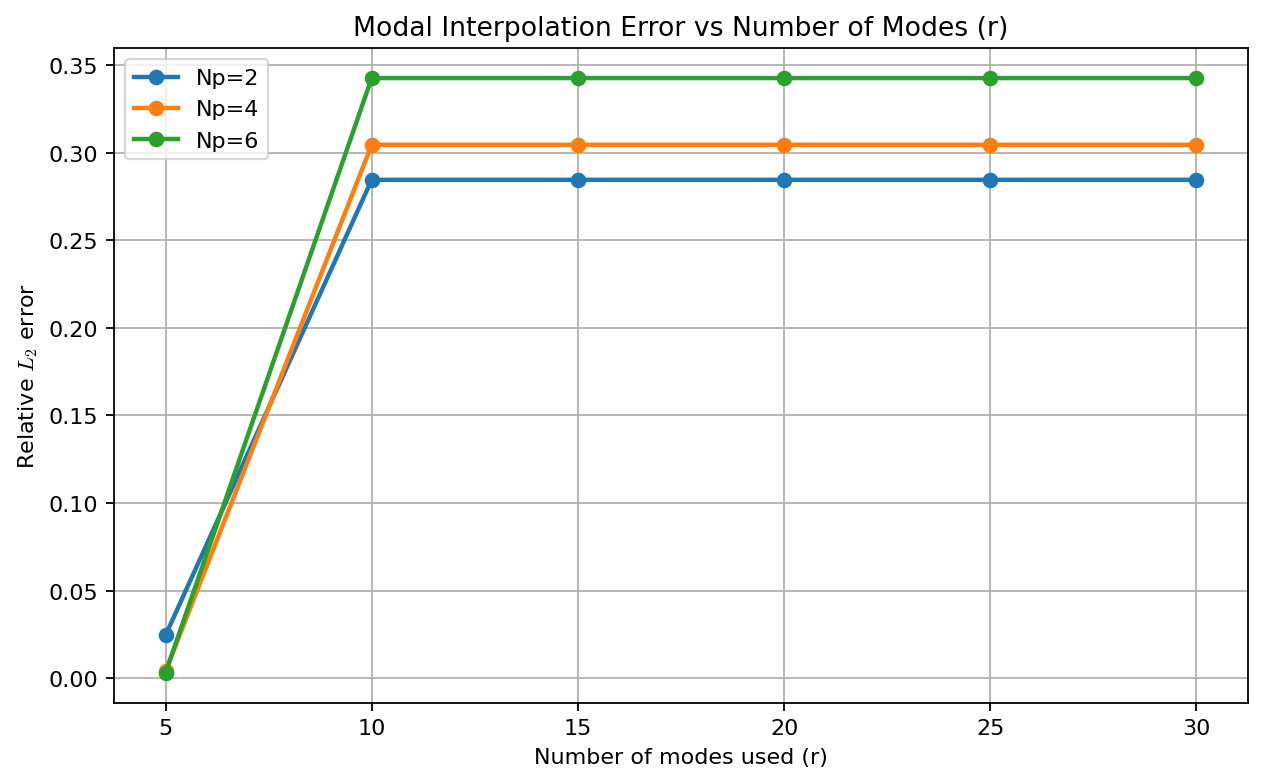

In [37]:
# Choose the number of modes you want to test
r_values = [5, 10, 15, 20, 25, 30]   # <-- you can change this

stencil_sizes = sorted(interp_modes_aligned.keys())
errors_modes_by_r = {Np: [] for Np in stencil_sizes}

print("\n=== Modal Interpolation Error for Selected r Values ===\n")

for Np in stencil_sizes:

    print(f"--- Stencil size Np = {Np} ---")


    # Predicted and true modes

    Phi_pred = interp_modes_aligned[Np]
    Phi_true = Phi_test_aligned

    # remove Cl row
    Phi_pred = Phi_pred[:-1, :]
    Phi_true = Phi_true[:-1, :]

    # remove DC mode
    Phi_pred = Phi_pred[:, 1:]
    Phi_true = Phi_true[:, 1:]

    # remove duplicate conjugate frequencies
    s_pred_full = interp_eigs_aligned[Np][1:]
    freqs_pred = s_pred_full.imag

    unique_idx = []
    used = set()
    for i, w in enumerate(freqs_pred):
        key = round(abs(float(w)), 8)
        if key not in used:
            used.add(key)
            unique_idx.append(i)

    Phi_pred = Phi_pred[:, unique_idx]
    Phi_true = Phi_true[:, unique_idx]

    # keep only odd indices (positive imaginary part)
    odd_idx = list(range(0, Phi_pred.shape[1], 2))
    Phi_pred = Phi_pred[:, odd_idx]
    Phi_true = Phi_true[:, odd_idx]


    # Compute modal error for each r

    for r in r_values:
        r_eff = min(r, Phi_pred.shape[1])  # safety
        mode_errors = []

        for j in range(r_eff):
            num = np.linalg.norm(Phi_pred[:, j] - Phi_true[:, j])
            den = np.linalg.norm(Phi_true[:, j])
            mode_errors.append(num / den)

        mean_err = np.mean(mode_errors)
        errors_modes_by_r[Np].append(mean_err)

        print(f"  r={r:2d}: mean modal error = {mean_err:.4e}")

# Plot
plt.figure(figsize=(8,5))

for Np in stencil_sizes:
    plt.plot(r_values, errors_modes_by_r[Np], "-o", linewidth=2, label=f"Np={Np}")

plt.xlabel("Number of modes used (r)")
plt.ylabel("Relative $L_2$ error")
plt.title("Modal Interpolation Error vs Number of Modes (r)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


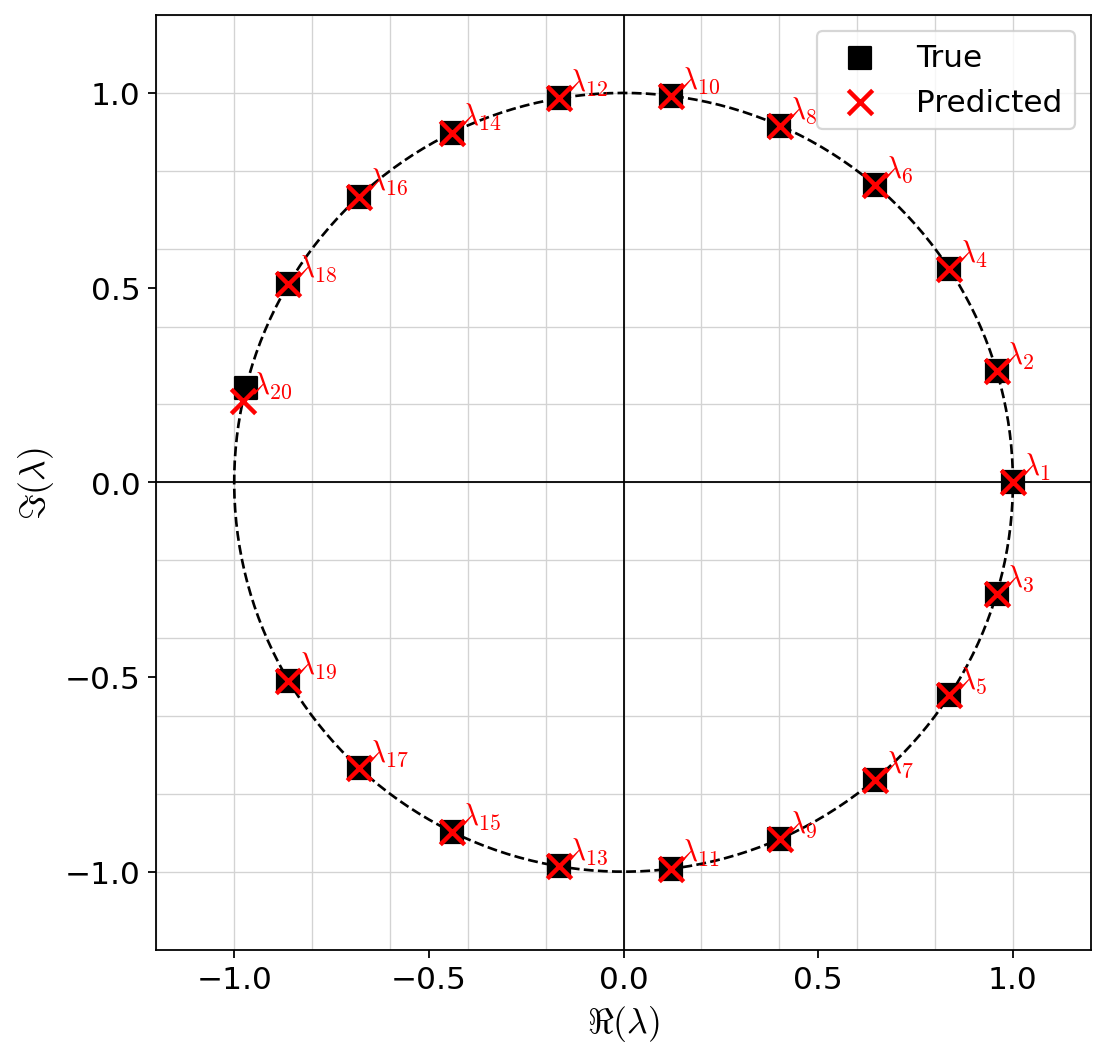

In [38]:
# Choose how many eigenvalues to plot
num_eigs = 20 

# Extract sampled times for the first Reynolds number
times = np.array(sampled_times_dict[Re_list[0]], dtype=float)
dt = times[1] - times[0]

# Convert continuous-time eigenvalues to discrete-time eigenvalues
z_interp = np.exp(s_interp * dt)
z_true   = np.exp(s_true   * dt)

# Slice the arrays
z_interp_plot = z_interp[:num_eigs]
z_true_plot   = z_true[:num_eigs]

fig, ax = plt.subplots(figsize=(7,7))

# BACKGROUND GRID
ax.grid(False)
grid_vals = np.linspace(-1.2, 1.2, 13)
for g in grid_vals:
    ax.plot([-1.2, 1.2], [g, g],
            color='lightgray', linewidth=0.6, zorder=0)
    ax.plot([g, g], [-1.2, 1.2],
            color='lightgray', linewidth=0.6, zorder=0)

# Axes
ax.axhline(0, color='black', linewidth=0.8, zorder=0)
ax.axvline(0, color='black', linewidth=0.8, zorder=0)

# UNIT CIRCLE
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta),
        linestyle='--', color='black', linewidth=1.2, zorder=1)

# TRUE EIGENVALUES
ax.scatter(z_true_plot.real, z_true_plot.imag,
           marker='s', s=90, color='black',
           edgecolor='black', linewidth=1.0,
           label="True", zorder=3)

# PREDICTED EIGENVALUES
ax.scatter(z_interp_plot.real, z_interp_plot.imag,
           marker='x', s=120, color='red',
           linewidth=2.0,
           label="Predicted", zorder=4)

# LABELS FOR EACH PREDICTED EIGENVALUE
dx, dy = 0.02, 0.02
for k, (xr, xi) in enumerate(zip(z_interp_plot.real, z_interp_plot.imag)):
    ax.text(xr + dx, xi + dy,
            rf"$\lambda_{{{k+1}}}$",
            fontsize=14, color='red', weight='bold',
            zorder=5)

# AXES + TITLES
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')

ax.set_xlabel(r"$\Re(\lambda)$", fontsize=16)
ax.set_ylabel(r"$\Im(\lambda)$", fontsize=16)

ax.tick_params(labelsize=14)

ax.legend(fontsize=14, loc="upper right")

plt.tight_layout()
plt.show()


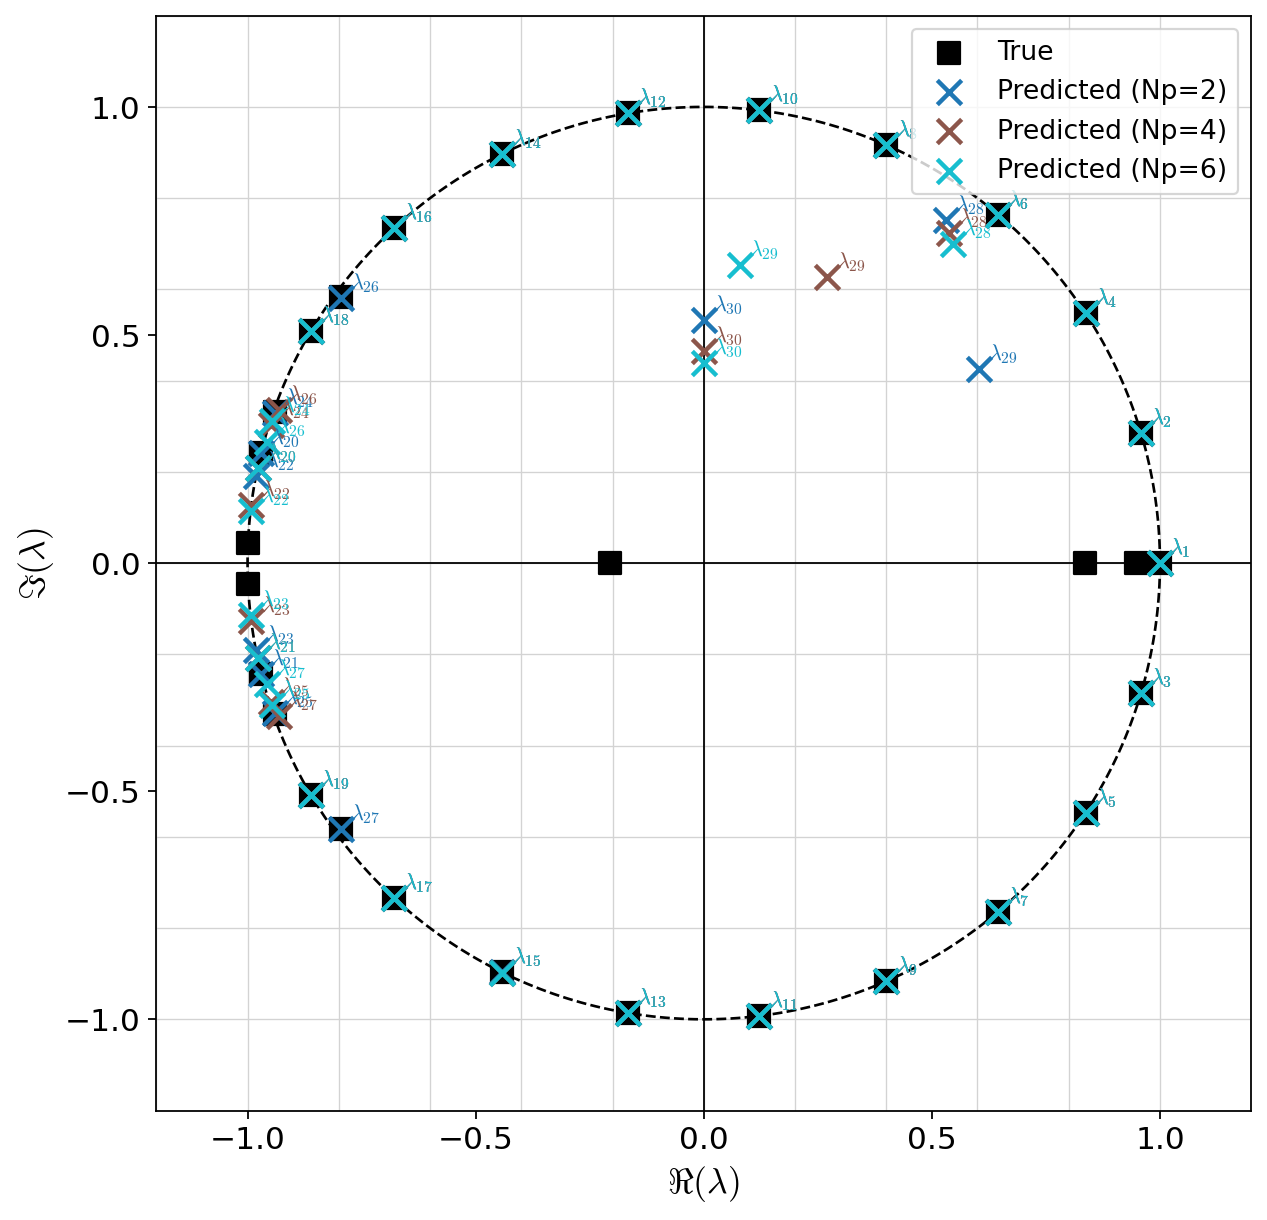

In [39]:

# SINGLE PLOT: Eigenvalues for ALL stencil sizes

num_eigs = 30

# TRUE eigenvalues (use the same 30 used in reconstruction)
s_true = ordered_eigs_test
            
z_true = np.exp(s_true * dt)
z_true_plot = z_true[:num_eigs]

fig, ax = plt.subplots(figsize=(8,8))

# Disable built‑in grid
ax.grid(False)

# Custom grid
grid_vals = np.linspace(-1.2, 1.2, 13)
for g in grid_vals:
    ax.plot([-1.2, 1.2], [g, g], color='lightgray', linewidth=0.6, zorder=0)
    ax.plot([g, g], [-1.2, 1.2], color='lightgray', linewidth=0.6, zorder=0)

# Axes
ax.axhline(0, color='black', linewidth=0.8, zorder=0)
ax.axvline(0, color='black', linewidth=0.8, zorder=0)

# Unit circle
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1.2, zorder=1)

# TRUE eigenvalues (only once)
ax.scatter(z_true_plot.real, z_true_plot.imag,
           marker='s', s=90, color='black',
           edgecolor='black', linewidth=1.0,
           label="True", zorder=3)

# PREDICTED eigenvalues for each stencil size
colors = plt.cm.tab10(np.linspace(0, 1, len(stencil_sets)))

for idx, Np in enumerate(stencil_sets.keys()):

    # Predicted continuous-time eigenvalues
    s_interp = interp_eigs_aligned[Np][:num_eigs]   # ensure 30 modes

    # Convert to discrete-time
    z_interp = np.exp(s_interp * dt)
    z_interp_plot = z_interp[:num_eigs]

    # Scatter
    ax.scatter(z_interp_plot.real, z_interp_plot.imag,
               marker='x', s=120, color=colors[idx],
               linewidth=2.0,
               label=f"Predicted (Np={Np})", zorder=4)

    # Labels
    dx, dy = 0.02, 0.02
    for k, (xr, xi) in enumerate(zip(z_interp_plot.real, z_interp_plot.imag)):
        ax.text(xr + dx, xi + dy,
                rf"$\lambda_{{{k+1}}}$",
                fontsize=10, color=colors[idx], zorder=5)

# Formatting
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')

ax.set_xlabel(r"$\Re(\lambda)$", fontsize=16)
ax.set_ylabel(r"$\Im(\lambda)$", fontsize=16)
ax.tick_params(labelsize=14)

ax.legend(loc="upper right", fontsize=12)

plt.tight_layout()
plt.show()
